# i. Introduction

Milestones 2

Name : Farras Annisa

Batch : HCK-027

This program is designed to develop a predictive model to estimate an individual's mental health state.

## Dataset Overview

The dataset used to develop this model consists of the following features:

* **User_ID**: A unique identifier for each respondent.
* **Age**: The age of each respondent.
* **Gender**: The respondent’s gender, categorized into three groups (Male, Female, Others), where *Others* refers to respondents who prefer not to disclose their gender (Prefer Not To Say).
* **Technology_Usage_Hours**: The amount of time spent per day (in hours) using electronic devices such as computers, smartphones, or tablets.
* **Social_Media_Usage_Hours**: The amount of time spent per day (in hours) accessing social media platforms (e.g., Instagram, Twitter, etc.).
* **Gaming_Hours**: The amount of time spent per day (in hours) playing games on mobile devices, consoles, or computers.
* **Screen_Time_Hours**: The total amount of time spent per day (in hours) looking at electronic device screens.
* **Mental_Health_Status**: The mental health status of each respondent, categorized as Poor, Fair, Good, or Excellent.
* **Stress_Level**: The respondent’s stress level, categorized as Low, Medium, or High.
* **Sleep_Hours**: The number of hours of sleep per day for each respondent.
* **Physical_Activity_Hours**: The amount of time spent per day (in hours) on physical activities such as exercise, walking, or other physical movements.
* **Support_Systems_Access**: Indicates whether the respondent has access to social or professional support systems, such as family, friends, therapists, or mental health services (Yes/No).
* **Work_Environment_Impact**: The respondent’s perception of how their work environment impacts their mental health, categorized as Positive, Neutral, or Negative.
* **Online_Support_Usage**: Indicates whether the respondent uses online mental health support services, such as online forums, counseling applications, or care groups (Yes/No).

## Problem Statement

As a healthcare institution specializing in mental health and operating for over 70 years, NAC has recently faced challenges in accurately determining the mental health status of individuals seeking treatment. This difficulty arises from the increasing number of influencing factors, particularly those related to technology usage.

As a result, NAC has frequently selected inappropriate therapy methods, leading to suboptimal treatment outcomes for patients. To address this issue and ensure more accurate treatment recommendations, seven predictive models and a baseline (Dummy) model will be developed and evaluated to determine which model performs best in predicting mental health status, and, just as importantly, whether the available features contain enough information to predict it at all.

## Objective

* To assist NAC, a mental health institution, in accurately diagnosing mental health status.

* To provide a structured guideline for the categorization of mental health status.

* To test, with a proper evaluation (baseline model, cross-validation, significance test against random guessing), whether the available features can predict `Mental_Health_Status`, so that the model is only recommended for use if it really works.

# ii. Import Libraries

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import binomtest, chi2_contingency, kendalltau

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, make_scorer, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

All libraries used in this project are imported once, here. Below is a brief explanation of each library:

* **Pandas** and **NumPy** are used for data manipulation, preprocessing, and table filtering.

* **SciPy** is used for statistical tests (Pearson and Kendall correlation, Chi-Square, ANOVA / t-test, and the binomial test against random guessing).

* **Matplotlib** and **Seaborn** are used for data visualization.

* **Pickle** is used to serialize and save the trained model into a file, and to load it again during the inference process.

* **Scikit-learn** is used to build the preprocessing pipeline, train, tune, and evaluate the models (Dummy, Logistic Regression, KNN, SVM, Decision Tree, Random Forest, MLP), and to run feature selection and permutation importance.

* **XGBoost** is used to implement the Extreme Gradient Boosting (XGBoost) model.

# iii. Data Loading

In [2]:
# Load the dataset into a DataFrame
data = pd.read_csv('P1M2_Farras_Annisa.csv')

# # Create a copy of the dataset
df = data.copy()

In [3]:
# Display the DataFrame
df

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,USER-09996,42,Male,7.05,0.41,0.53,13.90,Good,Medium,7.37,5.02,Yes,Neutral,No
9996,USER-09997,31,Other,3.12,6.79,0.80,1.17,Fair,Medium,8.92,9.78,No,Neutral,Yes
9997,USER-09998,23,Male,4.38,3.98,0.52,7.81,Poor,High,7.59,2.99,No,Positive,No
9998,USER-09999,38,Male,4.44,1.48,3.28,13.95,Poor,Medium,7.26,2.24,Yes,Neutral,Yes


In [4]:
# Check the target distribution
df['Mental_Health_Status'].value_counts()

Excellent    2518
Good         2508
Fair         2490
Poor         2484
Name: Mental_Health_Status, dtype: int64

Based on tables above the distribution across all four classes is nearly equal. The difference between the largest and smallest class is only 34 samples, which is negligible relative to the total dataset size

## Data Exploration

In [5]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   10000 non-null  object 
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   Technology_Usage_Hours    10000 non-null  float64
 4   Social_Media_Usage_Hours  10000 non-null  float64
 5   Gaming_Hours              10000 non-null  float64
 6   Screen_Time_Hours         10000 non-null  float64
 7   Mental_Health_Status      10000 non-null  object 
 8   Stress_Level              10000 non-null  object 
 9   Sleep_Hours               10000 non-null  float64
 10  Physical_Activity_Hours   10000 non-null  float64
 11  Support_Systems_Access    10000 non-null  object 
 12  Work_Environment_Impact   10000 non-null  object 
 13  Online_Support_Usage      10000 non-null  object 
dtypes: floa

In [6]:
# Check the column names

df.columns.to_list()

['User_ID',
 'Age',
 'Gender',
 'Technology_Usage_Hours',
 'Social_Media_Usage_Hours',
 'Gaming_Hours',
 'Screen_Time_Hours',
 'Mental_Health_Status',
 'Stress_Level',
 'Sleep_Hours',
 'Physical_Activity_Hours',
 'Support_Systems_Access',
 'Work_Environment_Impact',
 'Online_Support_Usage']

In [7]:
# Check missing values
df.isnull().sum()

User_ID                     0
Age                         0
Gender                      0
Technology_Usage_Hours      0
Social_Media_Usage_Hours    0
Gaming_Hours                0
Screen_Time_Hours           0
Mental_Health_Status        0
Stress_Level                0
Sleep_Hours                 0
Physical_Activity_Hours     0
Support_Systems_Access      0
Work_Environment_Impact     0
Online_Support_Usage        0
dtype: int64

In [8]:
# Check duplicated rows and whether User_ID is unique
print('Duplicated rows :', df.duplicated().sum())
print('User_ID unique  :', df['User_ID'].is_unique)

Duplicated rows : 0
User_ID unique  : True


In [9]:
# Display the first 10 rows
df.head(10)

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes
5,USER-00006,58,Male,5.59,5.74,0.11,1.34,Poor,Low,8.61,6.54,Yes,Neutral,Yes
6,USER-00007,63,Female,3.38,2.55,3.79,9.78,Excellent,Medium,8.61,1.34,Yes,Neutral,No
7,USER-00008,51,Female,7.18,4.10,4.74,8.14,Excellent,Medium,7.11,5.27,Yes,Neutral,No
8,USER-00009,57,Other,10.86,4.11,0.08,6.02,Fair,Medium,7.19,5.22,No,Positive,No
9,USER-00010,31,Other,4.30,7.23,0.81,6.87,Excellent,High,5.09,0.47,No,Positive,No


In [10]:
# Display the last 10 rows
df.tail(10)

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
9990,USER-09991,40,Male,8.91,5.91,4.25,13.73,Good,Low,5.87,7.67,No,Negative,Yes
9991,USER-09992,63,Female,7.32,6.39,0.13,13.57,Good,Low,6.99,7.90,Yes,Negative,Yes
9992,USER-09993,49,Male,1.66,6.36,4.24,4.55,Good,Medium,6.33,0.12,No,Neutral,No
9993,USER-09994,22,Female,11.58,5.42,0.75,11.88,Good,High,5.98,2.08,No,Positive,No
9994,USER-09995,51,Female,10.71,1.89,3.35,8.03,Fair,Medium,7.77,6.87,No,Neutral,No
9995,USER-09996,42,Male,7.05,0.41,0.53,13.90,Good,Medium,7.37,5.02,Yes,Neutral,No
9996,USER-09997,31,Other,3.12,6.79,0.80,1.17,Fair,Medium,8.92,9.78,No,Neutral,Yes
9997,USER-09998,23,Male,4.38,3.98,0.52,7.81,Poor,High,7.59,2.99,No,Positive,No
9998,USER-09999,38,Male,4.44,1.48,3.28,13.95,Poor,Medium,7.26,2.24,Yes,Neutral,Yes
9999,USER-10000,41,Male,2.50,4.80,0.25,8.82,Fair,Low,4.62,5.09,Yes,Positive,Yes


# iv. Feature Engineering part 1

### Check the data distribution

In [11]:
# Check the distribution

# Create a list based on the required columns
explore1 = ['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']

listexplore1 = []

# Iterate to determine the type of distribution (|skewness| <= 0.5 is treated as symmetric)
for column in explore1:
    listexplore1.append([column, (df[column].skew()), np.where(0.5 >= df[column].skew() >= -0.5, 'symmetric', 'skewed')])

# Store the result in a variable
skewness = pd.DataFrame(columns = ['Column', 'Skewness', 'Distribution Type'], data = listexplore1)
skewness

,Column,Skewness,Distribution Type
0,Age,0.005154,symmetric
1,Technology_Usage_Hours,0.018047,symmetric
2,Social_Media_Usage_Hours,0.010760,symmetric
3,Gaming_Hours,-0.023540,symmetric
4,Screen_Time_Hours,0.015484,symmetric
5,Sleep_Hours,0.004033,symmetric
6,Physical_Activity_Hours,0.000612,symmetric


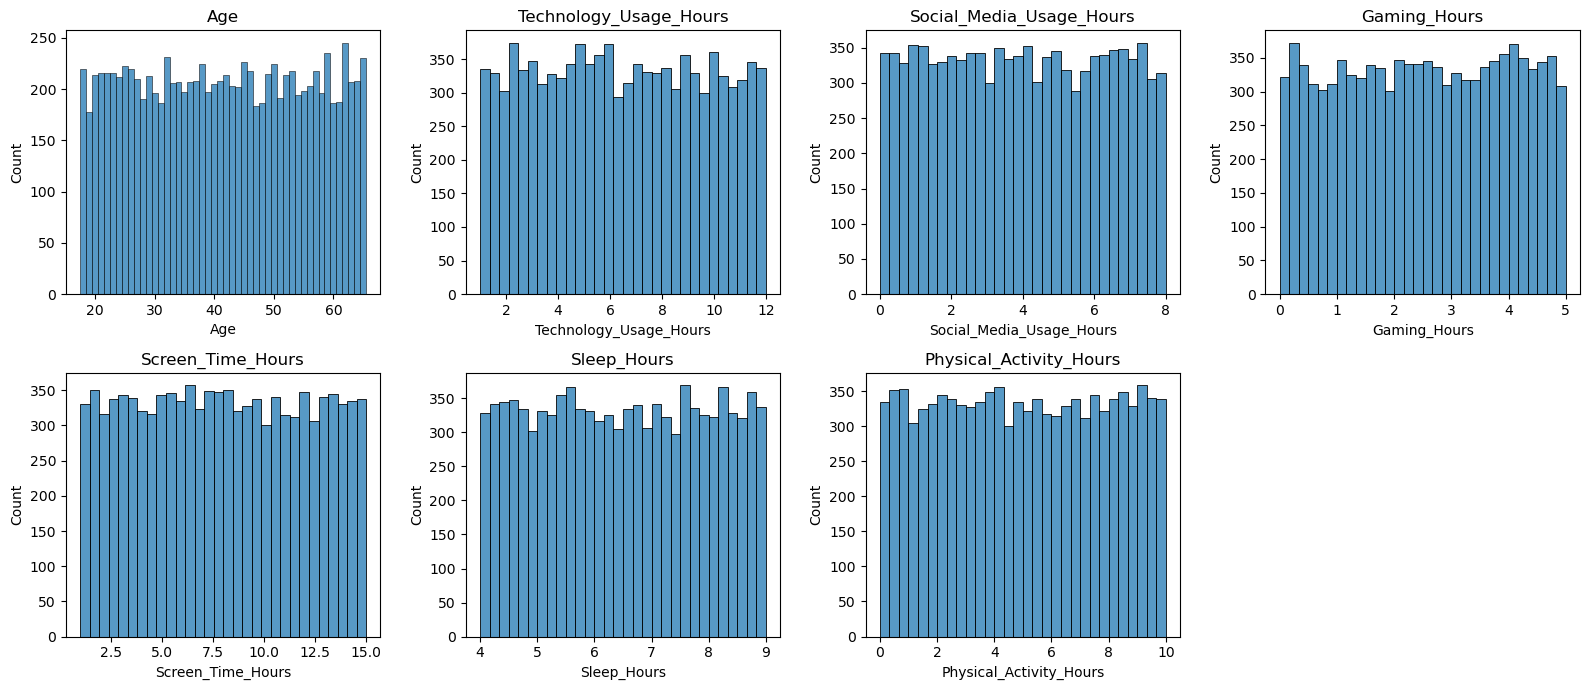

In [12]:
# Visualize the shape of every numerical column
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), explore1):
    sns.histplot(df[col], bins=30, discrete=(col == 'Age'), ax=ax)
    ax.set_title(col)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

Based on the table above, all numerical columns are **symmetric** (skewness is close to 0). The histograms show that their shape is closer to a **uniform** distribution than to a bell curve, so they are symmetric but not normally distributed. This does not change the choice of methods used below: the mean ± 3 standard deviations rule is used for outliers, and Pearson correlation and `StandardScaler` remain appropriate because the data are symmetric and the sample is large (10,000 rows).

### Check for outliers

In [13]:
# Calculate the upper and lower boundaries, and the percentage of outliers

# Create list
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Column'][row]

  # Check the upper and lower boundaries
  if skewness['Distribution Type'][row] == 'skewed':
    IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
    lower_boundary = df[col].quantile(0.25) - (IQR * 3)
    upper_boundary = df[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = df[col].mean() - 3* df[col].std()
    upper_boundary = df[col].mean() + 3* df[col].std()

  # Append list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(df[df[col] > upper_boundary]) / len(df) * 100) + (len(df[df[col] < lower_boundary]) / len(df) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    
    # Round the values
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [(percent_total_outlier) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,Age,83.28,-0.24,0.0
1,Technology_Usage_Hours,15.98,-3.03,0.0
2,Social_Media_Usage_Hours,10.91,-2.97,0.0
3,Gaming_Hours,6.86,-1.82,0.0
4,Screen_Time_Hours,20.10,-4.15,0.0
5,Sleep_Hours,10.85,2.15,0.0
6,Physical_Activity_Hours,13.72,-3.71,0.0


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,41.518600,13.920217,18.0,29.00,42.000,54.0000,65.0
Technology_Usage_Hours,10000.0,6.474341,3.169022,1.0,3.76,6.425,9.2125,12.0
Social_Media_Usage_Hours,10000.0,3.972321,2.313707,0.0,1.98,3.950,5.9900,8.0
Gaming_Hours,10000.0,2.515598,1.446748,0.0,1.26,2.520,3.7900,5.0
Screen_Time_Hours,10000.0,7.975765,4.042608,1.0,4.52,7.900,11.5000,15.0
Sleep_Hours,10000.0,6.500724,1.450933,4.0,5.26,6.500,7.7600,9.0
Physical_Activity_Hours,10000.0,5.003860,2.905044,0.0,2.49,4.990,7.5400,10.0


Based on the table above, none of the columns contain outliers (0.0%), and every column stays within a plausible range (for example Age 18-65, Sleep_Hours 4-9, Gaming_Hours 0-5).

# v. Exploratory Data Analysis

## 1. What is the correlation between 'Social_Media_Usage_Hours', 'Gaming_Hours', and 'Screen_Time_Hours' with 'Technology_Usage_Hours'?

Pearson correlation is used. The numerical variables are symmetric (skewness close to 0) and the sample is large (10,000 rows), so Pearson is appropriate. The strength of a correlation is judged by the size of the coefficient: |r| < 0.1 is negligible, 0.1-0.3 weak, 0.3-0.5 moderate, and above 0.5 strong. With 10,000 rows even a negligible correlation can reach p < 0.05, so the p-value alone is not enough. Three correlations are tested here, so a Bonferroni threshold of 0.05 / 3 ≈ 0.017 is also kept in mind.

In [15]:
# Strength of a correlation based on the absolute coefficient
def corr_strength(r):
    r = abs(r)
    if r < 0.1:
        return 'negligible'
    elif r < 0.3:
        return 'weak'
    elif r < 0.5:
        return 'moderate'
    return 'strong'

# Iterate to check the correlation using the Pearson method
listEDA1 = ['Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours']
ResultEDA1 = []

for column in listEDA1:
    corr_coef, p_value = stats.pearsonr(df[column], df['Technology_Usage_Hours'])

    if p_value < 0.05:
        status = 'There is a correlation'
    else:
        status = 'There is no correlation'

    ResultEDA1.append([column, p_value, corr_coef, corr_strength(corr_coef), status])

# Display the results table
pd.DataFrame(columns=['Column', 'P-Value', 'Correlation', 'Strength', 'Conclusion'], data=ResultEDA1)

,Column,P-Value,Correlation,Strength,Conclusion
0,Social_Media_Usage_Hours,0.020345,0.023199,negligible,There is a correlation
1,Gaming_Hours,0.150908,0.014364,negligible,There is no correlation
2,Screen_Time_Hours,0.426868,0.007947,negligible,There is no correlation


From the table, 'Social_Media_Usage_Hours' is statistically correlated with 'Technology_Usage_Hours' at the 0.05 level (p = 0.020), but the coefficient is only r = 0.023, which is **negligible** (it explains about 0.05% of the variance), and the result is not significant after the Bonferroni correction (0.017). With 10,000 rows, such a tiny coefficient reaches p < 0.05 easily. 'Gaming_Hours' and 'Screen_Time_Hours' show no significant correlation with 'Technology_Usage_Hours'.

In practice, none of the three variables is related to 'Technology_Usage_Hours'. This is surprising, because social media, gaming, and screen time are all part of technology use. The next check looks at whether these columns are logically consistent with each other.

In [16]:
# Logical consistency check of the usage columns, based on their definitions in the Introduction
# (social media and gaming happen on electronic devices, so they should not exceed the total device usage)
consistency = pd.Series({
    'Social_Media_Usage_Hours > Technology_Usage_Hours': (df['Social_Media_Usage_Hours'] > df['Technology_Usage_Hours']).mean(),
    'Gaming_Hours > Technology_Usage_Hours': (df['Gaming_Hours'] > df['Technology_Usage_Hours']).mean(),
    'Screen_Time_Hours > Technology_Usage_Hours': (df['Screen_Time_Hours'] > df['Technology_Usage_Hours']).mean(),
    'Sleep + Physical activity + Screen time > 24 hours': ((df['Sleep_Hours'] + df['Physical_Activity_Hours'] + df['Screen_Time_Hours']) > 24).mean()
})
(consistency * 100).round(1).rename('% of respondents')

Social_Media_Usage_Hours > Technology_Usage_Hours     27.4
Gaming_Hours > Technology_Usage_Hours                 14.2
Screen_Time_Hours > Technology_Usage_Hours            60.5
Sleep + Physical activity + Screen time > 24 hours    21.0
Name: % of respondents, dtype: float64

These columns contradict each other for a large share of respondents: for example, 27% of respondents spend more hours on social media than their total technology usage, and 21% have sleep, physical activity, and screen time that add up to more than 24 hours. Together with the near-zero correlations above, this suggests that the usage columns were recorded (or generated) independently of each other, which is a data-quality warning for the modeling that follows.

## 2. What is the correlation between 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', and 'Technology_Usage_Hours' with 'Sleep_Hours'?

In [17]:
# Iterate to check the correlation using the Pearson method

listEDA2 = ['Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Technology_Usage_Hours']
ResultEDA2 = []

for column in listEDA2:
    corr_coef, p_value = stats.pearsonr(df[column], df['Sleep_Hours'])

    if p_value < 0.05:
        status = 'There is a correlation'
    else:
        status = 'There is no correlation'

    ResultEDA2.append([column, p_value, corr_coef, status])

# Display the results table
pd.DataFrame(columns=['Column', 'P-Value', 'Correlation', 'Conclusion'], data=ResultEDA2)

,Column,P-Value,Correlation,Conclusion
0,Social_Media_Usage_Hours,0.656842,0.004443,There is no correlation
1,Gaming_Hours,0.298728,0.010393,There is no correlation
2,Screen_Time_Hours,0.263588,-0.011181,There is no correlation
3,Physical_Activity_Hours,0.317566,-0.009996,There is no correlation
4,Technology_Usage_Hours,0.326940,-0.009804,There is no correlation


Based on the table above, **'Social_Media_Usage_Hours'**, **'Gaming_Hours'**, **'Screen_Time_Hours'**, **'Physical_Activity_Hours'**, and **'Technology_Usage_Hours'** do not show a significant correlation with **'Sleep_Hours'** (all p-values are above 0.25 and all coefficients are about 0.01).

## 3. Is there a significant difference in the average of 'Technology_Usage_Hours' across each 'Stress_Level' category?

In [18]:
# Category order used in the charts (lowest to highest)
order_stress = ['Low', 'Medium', 'High']
order_work = ['Positive', 'Neutral', 'Negative']
order_yesno = ['Yes', 'No']
order_mental = ['Poor', 'Fair', 'Good', 'Excellent']


# Helper: bar chart of the mean of a numerical column per category
def plot_group_mean(data, value_col, group_col, order, palette, title, xlabel, ylabel, figsize=(5, 5)):
    means = data.groupby(group_col)[value_col].mean().reindex(order)

    plt.figure(figsize=figsize)
    sns.barplot(x=means.index, y=means.values, hue=means.index, palette=palette, legend=False)

    for i, val in enumerate(means.values):
        plt.text(i, val + 0.03, f"{val:.3f}", ha='center', va='bottom')

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.show()


# Helper: test whether the mean differs between the categories
# (Welch t-test for 2 categories, one-way ANOVA for 3 or more)
def compare_groups(data, value_col, group_col):
    groups = [g[value_col].values for _, g in data.groupby(group_col)]

    if len(groups) == 2:
        test_name = 'Welch t-test'
        p_value = stats.ttest_ind(*groups, equal_var=False).pvalue
    else:
        test_name = 'One-way ANOVA'
        p_value = stats.f_oneway(*groups).pvalue

    means = data.groupby(group_col)[value_col].mean()
    verdict = 'significant at 0.05' if p_value < 0.05 else 'not significant'
    print(f"{test_name}: p-value = {p_value:.3f} ({verdict})")
    print(f"Highest mean: {means.idxmax()} ({means.max():.3f}) | lowest mean: {means.idxmin()} ({means.min():.3f}) | difference: {means.max() - means.min():.3f} hours")

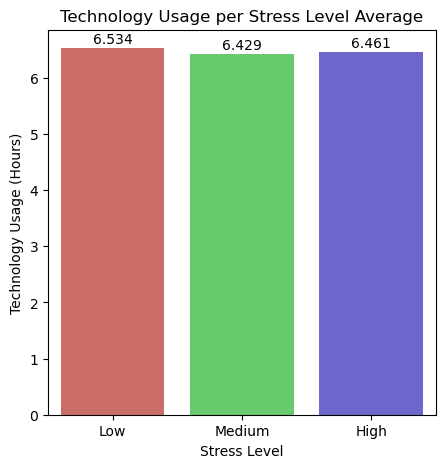

One-way ANOVA: p-value = 0.382 (not significant)
Highest mean: Low (6.534) | lowest mean: Medium (6.429) | difference: 0.105 hours


In [19]:
plot_group_mean(df, 'Technology_Usage_Hours', 'Stress_Level', order_stress, 'hls',
                'Technology Usage per Stress Level Average', 'Stress Level', 'Technology Usage (Hours)')
compare_groups(df, 'Technology_Usage_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Technology_Usage_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.382). The **Low** stress level has the highest mean (6.53 hours), but it is only about 0.1 hour (6 minutes) higher than the other groups.

## 4. Is there a significant difference in the average of 'Social_Media_Usage_Hours' across each 'Stress_Level' category?

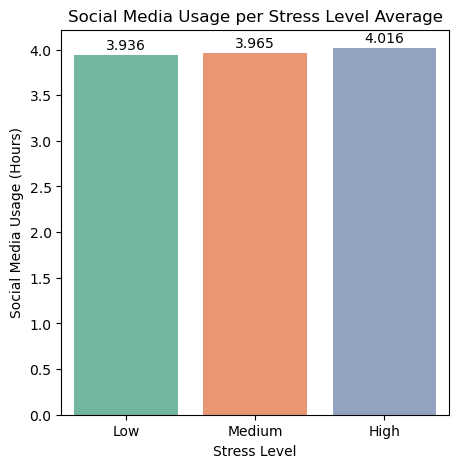

One-way ANOVA: p-value = 0.360 (not significant)
Highest mean: High (4.016) | lowest mean: Low (3.936) | difference: 0.080 hours


In [20]:
plot_group_mean(df, 'Social_Media_Usage_Hours', 'Stress_Level', order_stress, 'Set2',
                'Social Media Usage per Stress Level Average', 'Stress Level', 'Social Media Usage (Hours)')
compare_groups(df, 'Social_Media_Usage_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Social_Media_Usage_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.360). The **High** stress level has the highest mean (4.02 hours), but the gap to the lowest group is only about 0.08 hour (5 minutes).

## 5. Is there a significant difference in the average of 'Gaming_Hours' across each 'Stress_Level' category?


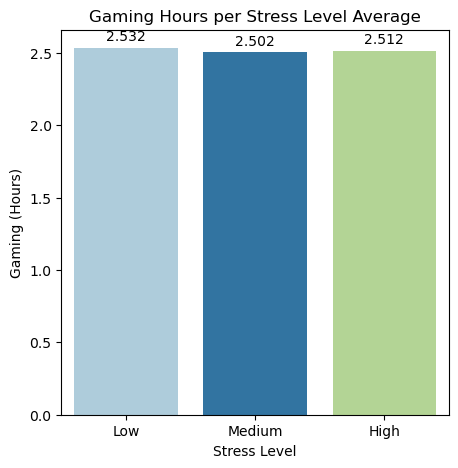

One-way ANOVA: p-value = 0.696 (not significant)
Highest mean: Low (2.532) | lowest mean: Medium (2.502) | difference: 0.030 hours


In [21]:
plot_group_mean(df, 'Gaming_Hours', 'Stress_Level', order_stress, 'Paired',
                'Gaming Hours per Stress Level Average', 'Stress Level', 'Gaming (Hours)')
compare_groups(df, 'Gaming_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Gaming_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.696). The **Low** stress level has the highest mean (2.53 hours), but the gap is only about 0.03 hour.

## 6. Is there a significant difference in the average of 'Screen_Time_Hours' across each 'Stress_Level' category?

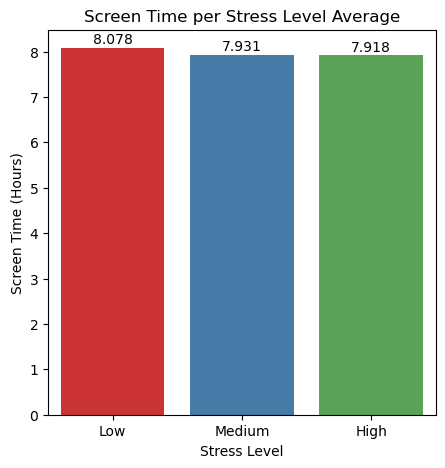

One-way ANOVA: p-value = 0.200 (not significant)
Highest mean: Low (8.078) | lowest mean: High (7.918) | difference: 0.160 hours


In [22]:
plot_group_mean(df, 'Screen_Time_Hours', 'Stress_Level', order_stress, 'Set1',
                'Screen Time per Stress Level Average', 'Stress Level', 'Screen Time (Hours)')
compare_groups(df, 'Screen_Time_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Screen_Time_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.200). The **Low** stress level has the highest mean (8.08 hours), but it is only about 0.16 hour (10 minutes) higher than the other groups.

## 7. Is there a significant difference in the average of 'Sleep_Hours' across each 'Stress_Level' category?

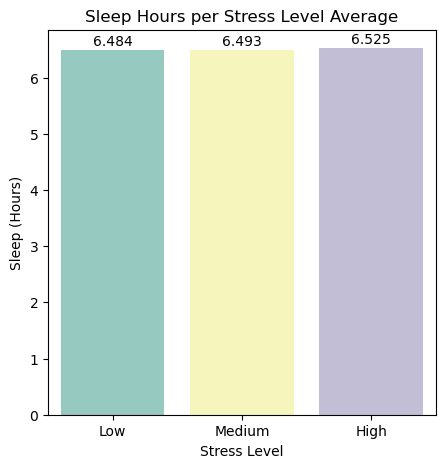

One-way ANOVA: p-value = 0.478 (not significant)
Highest mean: High (6.525) | lowest mean: Low (6.484) | difference: 0.041 hours


In [23]:
plot_group_mean(df, 'Sleep_Hours', 'Stress_Level', order_stress, 'Set3',
                'Sleep Hours per Stress Level Average', 'Stress Level', 'Sleep (Hours)')
compare_groups(df, 'Sleep_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Sleep_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.478). The **High** stress level has the highest mean (6.53 hours), but the gap is only about 0.04 hour.

## 8. Is there a significant difference in the average of 'Physical_Activity_Hours' across each 'Stress_Level' category?


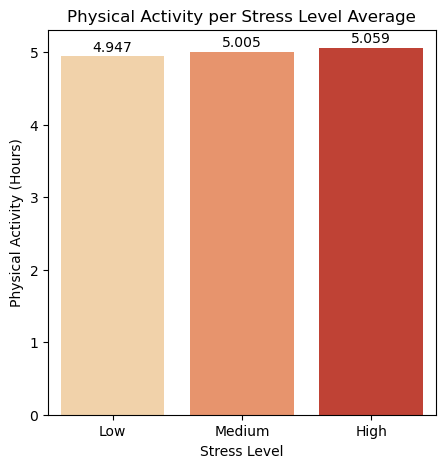

One-way ANOVA: p-value = 0.291 (not significant)
Highest mean: High (5.059) | lowest mean: Low (4.947) | difference: 0.112 hours


In [24]:
plot_group_mean(df, 'Physical_Activity_Hours', 'Stress_Level', order_stress, 'OrRd',
                'Physical Activity per Stress Level Average', 'Stress Level', 'Physical Activity (Hours)')
compare_groups(df, 'Physical_Activity_Hours', 'Stress_Level')

Based on the chart and the ANOVA test above, the mean **'Physical_Activity_Hours'** does not differ significantly across the **'Stress_Level'** categories (p = 0.291). The **High** stress level has the highest mean (5.06 hours), but the gap to the lowest group is only about 0.11 hour.

## 9. Is there a significant difference in the average of 'Sleep_Hours' across each 'Work_Environment_Impact' category?

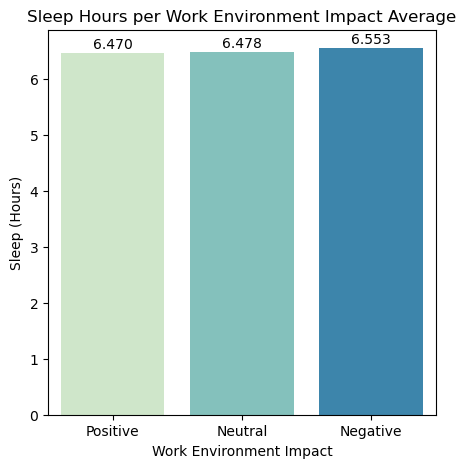

One-way ANOVA: p-value = 0.036 (significant at 0.05)
Highest mean: Negative (6.553) | lowest mean: Positive (6.470) | difference: 0.083 hours


In [25]:
plot_group_mean(df, 'Sleep_Hours', 'Work_Environment_Impact', order_work, 'GnBu',
                'Sleep Hours per Work Environment Impact Average', 'Work Environment Impact', 'Sleep (Hours)')
compare_groups(df, 'Sleep_Hours', 'Work_Environment_Impact')

Based on the chart and the ANOVA test above, the difference in mean **'Sleep_Hours'** across the **'Work_Environment_Impact'** categories is statistically significant at the 0.05 level (p = 0.036), with the **Negative** category having the highest mean (6.55 hours) and the **Positive** category the lowest (6.47 hours). However, the difference is only about 0.08 hour (5 minutes), which is practically negligible, and it does not survive a Bonferroni correction for the 10 group comparisons in this section (0.05 / 10 = 0.005). It is most likely a chance finding.

## 10. Is there a significant difference in the average of 'Technology_Usage_Hours' across each 'Support_Systems_Access' category?

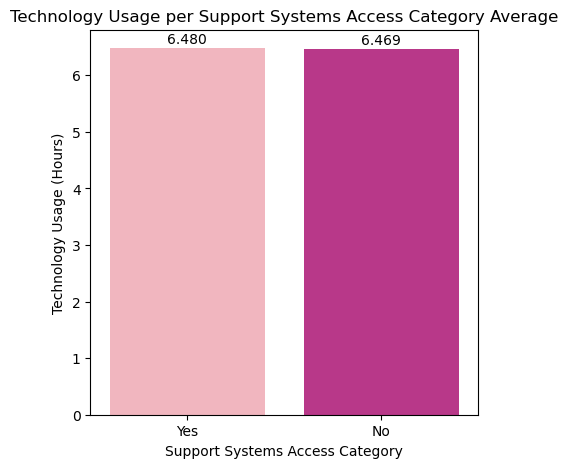

Welch t-test: p-value = 0.854 (not significant)
Highest mean: Yes (6.480) | lowest mean: No (6.469) | difference: 0.012 hours


In [26]:
plot_group_mean(df, 'Technology_Usage_Hours', 'Support_Systems_Access', order_yesno, 'RdPu',
                'Technology Usage per Support Systems Access Category Average', 'Support Systems Access Category', 'Technology Usage (Hours)')
compare_groups(df, 'Technology_Usage_Hours', 'Support_Systems_Access')

Based on the chart and the Welch t-test above, the mean **'Technology_Usage_Hours'** does not differ significantly between respondents with and without **'Support_Systems_Access'** (p = 0.854). The two means are 6.48 hours (Yes) and 6.47 hours (No).

## 11. Is there a significant difference in the average of 'Technology_Usage_Hours' across each 'Online_Support_Usage' category?

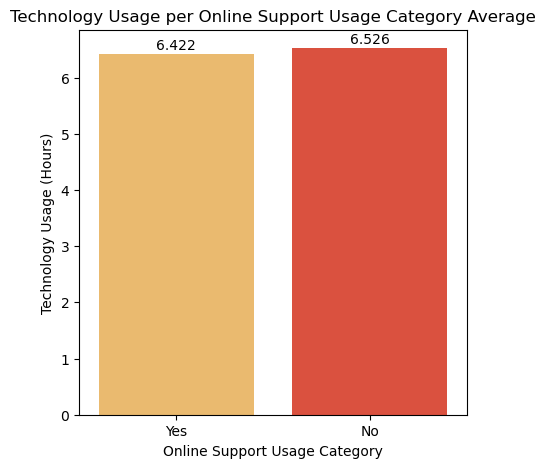

Welch t-test: p-value = 0.099 (not significant)
Highest mean: No (6.526) | lowest mean: Yes (6.422) | difference: 0.104 hours


In [27]:
plot_group_mean(df, 'Technology_Usage_Hours', 'Online_Support_Usage', order_yesno, 'YlOrRd',
                'Technology Usage per Online Support Usage Category Average', 'Online Support Usage Category', 'Technology Usage (Hours)')
compare_groups(df, 'Technology_Usage_Hours', 'Online_Support_Usage')

Based on the chart and the Welch t-test above, the mean **'Technology_Usage_Hours'** does not differ significantly between respondents who use online support services and those who do not (p = 0.099). Respondents who do not use them (**No**) have the higher mean (6.53 vs 6.42 hours), but the gap is only about 0.1 hour.

## 12. Is there a significant difference in the average 'Sleep_Hours' across the categories of 'Mental_Health_Status'?

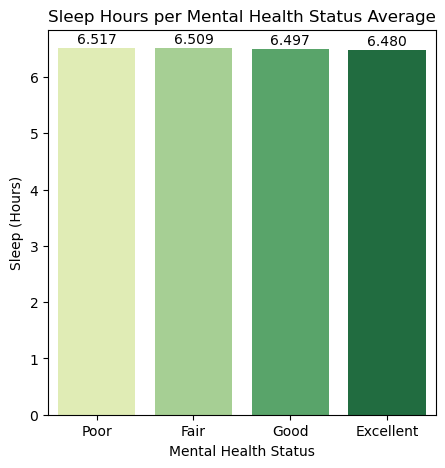

One-way ANOVA: p-value = 0.825 (not significant)
Highest mean: Poor (6.517) | lowest mean: Excellent (6.480) | difference: 0.036 hours


In [28]:
plot_group_mean(df, 'Sleep_Hours', 'Mental_Health_Status', order_mental, 'YlGn',
                'Sleep Hours per Mental Health Status Average', 'Mental Health Status', 'Sleep (Hours)')
compare_groups(df, 'Sleep_Hours', 'Mental_Health_Status')

Based on the chart and the ANOVA test above, the mean **'Sleep_Hours'** does not differ significantly across the **'Mental_Health_Status'** categories (p = 0.825). The **Poor** status has the highest mean (6.52 hours) and **Excellent** the lowest (6.48 hours), a gap of only 0.04 hour. Sleep duration does not separate the mental health groups.

## 13. How is the distribution of **'Stress_Level'** across each age category (10s–60s)?

In [29]:
# Age categories function
def categorize_age(age):
    if 18 <= age <= 19:
        return "10's"
    elif 20 <= age <= 29:
        return "20's"
    elif 30 <= age <= 39:
        return "30's"
    elif 40 <= age <= 49:
        return "40's"
    elif 50 <= age <= 59:
        return "50's"
    elif 60 <= age <= 69:
        return "60's"
    else:
        return 'Other'


AgeOrder = ["10's", "20's", "30's", "40's", "50's", "60's"]

# A separate DataFrame is used, so the AgeGroup column never enters the model features later
dfAge = df.assign(AgeGroup=df['Age'].apply(categorize_age))
dfAge = dfAge[dfAge['AgeGroup'].isin(AgeOrder)]

# Number of respondents per age group
dfAge['AgeGroup'].value_counts().reindex(AgeOrder)

10's     398
20's    2129
30's    2059
40's    2060
50's    2091
60's    1263
Name: AgeGroup, dtype: int64

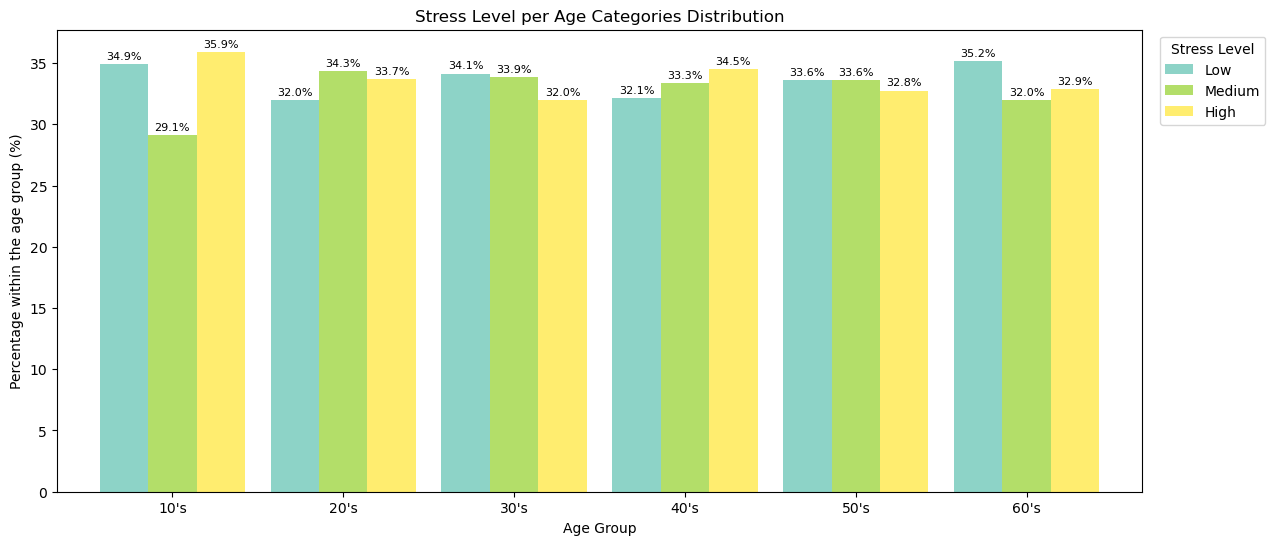

Chi-Square test of independence: p-value = 0.372 (not significant at 0.05)


In [30]:
# Helper: percentage of every category of a target within each age group, plus a Chi-Square test of independence
def plot_age_distribution(target_col, order, palette, title, legend_title):
    pct = (pd.crosstab(dfAge['AgeGroup'], dfAge[target_col], normalize='index') * 100).reindex(AgeOrder)[order]

    ax = pct.plot(kind='bar', figsize=(14, 6), colormap=palette, width=0.85, rot=0)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

    ax.set_title(title)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Percentage within the age group (%)')
    ax.legend(title=legend_title, loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.show()

    chi2, p_value, _, _ = chi2_contingency(pd.crosstab(dfAge['AgeGroup'], dfAge[target_col]))
    print(f"Chi-Square test of independence: p-value = {p_value:.3f} ({'significant' if p_value < 0.05 else 'not significant'} at 0.05)")


plot_age_distribution('Stress_Level', order_stress, 'Set3',
                      'Stress Level per Age Categories Distribution', 'Stress Level')

Based on the chart and the Chi-Square test above, the distribution of **'Stress_Level'** does not depend on the age group (p = 0.372): in every age group each stress level covers roughly 29-36% of the respondents. The apparent differences are small and not statistically significant: **Low** is highest in the 60s (35.2%), **Medium** in the 20s (34.3%), and **High** in the 10s (35.9%). The 10s group is also the smallest (398 respondents), so its percentages are the least stable.

## 14. How is the distribution of **'Mental_Health_Status'** across each age category (10s–60s)?


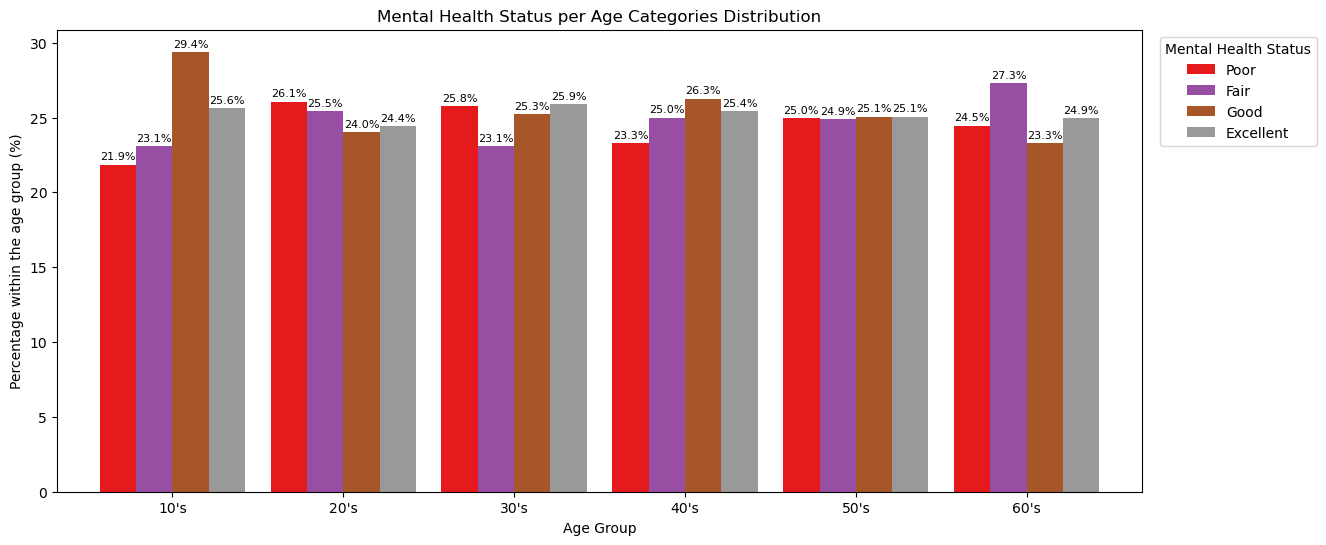

Chi-Square test of independence: p-value = 0.183 (not significant at 0.05)


In [31]:
plot_age_distribution('Mental_Health_Status', order_mental, 'Set1',
                      'Mental Health Status per Age Categories Distribution', 'Mental Health Status')

Based on the chart and the Chi-Square test above, the distribution of **'Mental_Health_Status'** does not depend on the age group (p = 0.183): every status covers roughly 22-29% of each age group. The highest percentages are **Poor** in the 20s (26.1%), **Fair** in the 60s (27.3%), **Good** in the 10s (29.4%), and **Excellent** in the 30s (25.9%), but these differences are not statistically significant.

# vi. Feature Engineering part 2

## Split data into X (Features) and y (Target)

In [32]:
# Split the data into features and target

# Features values
X = df.drop(columns = ['Mental_Health_Status', 'User_ID'])

# Target values
yRaw = df['Mental_Health_Status']

Drop the 'User_ID' column from the features because it does not contain meaningful information and only represents a unique identifier for each respondent.

In [33]:
# Features
X

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,23,Female,6.57,6.00,0.68,12.36,Low,8.01,6.71,No,Negative,Yes
1,21,Male,3.01,2.57,3.74,7.61,High,7.28,5.88,Yes,Positive,No
2,51,Male,3.04,6.14,1.26,3.16,High,8.04,9.81,No,Negative,No
3,25,Female,3.84,4.48,2.59,13.08,Medium,5.62,5.28,Yes,Negative,Yes
4,53,Male,1.20,0.56,0.29,12.63,Low,5.55,4.00,No,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42,Male,7.05,0.41,0.53,13.90,Medium,7.37,5.02,Yes,Neutral,No
9996,31,Other,3.12,6.79,0.80,1.17,Medium,8.92,9.78,No,Neutral,Yes
9997,23,Male,4.38,3.98,0.52,7.81,High,7.59,2.99,No,Positive,No
9998,38,Male,4.44,1.48,3.28,13.95,Medium,7.26,2.24,Yes,Neutral,Yes


In [34]:
# Target
yRaw

0            Good
1            Poor
2            Fair
3       Excellent
4            Good
          ...    
9995         Good
9996         Fair
9997         Poor
9998         Poor
9999         Fair
Name: Mental_Health_Status, Length: 10000, dtype: object

In [35]:
# Mapping based on the mental health status categories
mapping = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

# astype(int) makes sure the target is a plain integer column
y = yRaw.map(mapping).astype(int)

In [36]:
y

0       2
1       0
2       1
3       3
4       2
       ..
9995    2
9996    1
9997    0
9998    0
9999    1
Name: Mental_Health_Status, Length: 10000, dtype: int64

## Splitting data into Train set and Test set

In [37]:
# Split the data into a training set and a test set
# stratify = y keeps the class proportions of the 4 target classes identical in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 30)

print(f"Train Set shape: {X_train.shape}")
print(f"Test Set shape: {X_test.shape}")

# Sanity check: class proportions in train and test
print("\nClass proportions - Train:\n", y_train.value_counts(normalize = True).sort_index().round(3))
print("\nClass proportions - Test:\n", y_test.value_counts(normalize = True).sort_index().round(3))

Train Set shape: (8000, 12)
Test Set shape: (2000, 12)

Class proportions - Train:
 0    0.248
1    0.249
2    0.251
3    0.252
Name: Mental_Health_Status, dtype: float64

Class proportions - Test:
 0    0.248
1    0.249
2    0.250
3    0.252
Name: Mental_Health_Status, dtype: float64


In [38]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8000 entries, 8877 to 9934
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       8000 non-null   int64  
 1   Gender                    8000 non-null   object 
 2   Technology_Usage_Hours    8000 non-null   float64
 3   Social_Media_Usage_Hours  8000 non-null   float64
 4   Gaming_Hours              8000 non-null   float64
 5   Screen_Time_Hours         8000 non-null   float64
 6   Stress_Level              8000 non-null   object 
 7   Sleep_Hours               8000 non-null   float64
 8   Physical_Activity_Hours   8000 non-null   float64
 9   Support_Systems_Access    8000 non-null   object 
 10  Work_Environment_Impact   8000 non-null   object 
 11  Online_Support_Usage      8000 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 812.5+ KB


## Define column groups

The column lists and the ordinal category order are defined **once, up front**, and reused by the correlation tests, feature selection, and the pipeline so that the encoding is consistent at every stage.

In [39]:
# Column groups by feature type
NumericalColumns = [
    'Age',
    'Technology_Usage_Hours',
    'Social_Media_Usage_Hours',
    'Gaming_Hours',
    'Screen_Time_Hours',
    'Sleep_Hours',
    'Physical_Activity_Hours'
]

NominalColumns = [
    'Gender',
    'Support_Systems_Access',
    'Online_Support_Usage'
]

OrdinalColumns = [
    'Stress_Level',
    'Work_Environment_Impact'
]

# Ordinal order (lowest to highest). Also used by the Kendall's Tau test below.
OrdinalCategories = [
    ['Low', 'Medium', 'High'],          # Stress_Level
    ['Positive', 'Neutral', 'Negative'] # Work_Environment_Impact
]

## Check the correlation between categorical and numerical columns with the target

### Check the correlation between categorical columns

In [40]:
# List of categorical features
listFE2Categorical = ['Gender', 'Support_Systems_Access', 'Online_Support_Usage']

ResultFE2Categorical = []

# Target for the train rows only (selected through the X_train index so that no test data leaks in)
yRaw_train = yRaw.loc[X_train.index]

for col in listFE2Categorical:

    contingency_table = pd.crosstab(X_train[col], yRaw_train)

    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    status = 'There is a correlation' if p_value < 0.05 else 'There is no correlation'

    ResultFE2Categorical.append({
        'Feature': col,
        'Chi-Square': round(chi2, 3),
        'p-value': round(p_value, 3),
        'Status': status
    })

pd.DataFrame(ResultFE2Categorical)

,Feature,Chi-Square,p-value,Status
0,Gender,2.918,0.819,There is no correlation
1,Support_Systems_Access,6.445,0.092,There is no correlation
2,Online_Support_Usage,0.154,0.985,There is no correlation


### Check the correlation between numerical and categorical (ordinal) columns

In [41]:
# Kendall's Tau needs values that can be ranked. The ordinal (text) columns must be encoded first,
# following OrdinalCategories. If they are passed as raw strings, the ranking becomes alphabetical
# (High < Low < Medium) and the correlation is wrong.
ordinal_encoded = pd.DataFrame(
    OrdinalEncoder(categories = OrdinalCategories).fit_transform(X_train[OrdinalColumns]),
    columns = OrdinalColumns,
    index = X_train.index
)

X_train_kendall = pd.concat([X_train[NumericalColumns], ordinal_encoded], axis = 1)

ResultFE2Numerical = []

for col in X_train_kendall.columns:
    corr_coef, p_value = kendalltau(X_train_kendall[col], y_train)

    status = 'There is a correlation' if p_value < 0.05 else 'There is no correlation'

    ResultFE2Numerical.append({
        'Feature': col,
        'Kendall Tau': round(corr_coef, 3),
        'p-value': round(p_value, 3),
        'Status': status
    })

pd.DataFrame(ResultFE2Numerical)

,Feature,Kendall Tau,p-value,Status
0,Age,-0.009,0.270,There is no correlation
1,Technology_Usage_Hours,0.002,0.829,There is no correlation
2,Social_Media_Usage_Hours,-0.006,0.478,There is no correlation
3,Gaming_Hours,-0.005,0.526,There is no correlation
4,Screen_Time_Hours,0.007,0.424,There is no correlation
5,Sleep_Hours,-0.011,0.184,There is no correlation
6,Physical_Activity_Hours,0.002,0.812,There is no correlation
7,Stress_Level,0.004,0.698,There is no correlation
8,Work_Environment_Impact,0.001,0.898,There is no correlation


## Feature Selection

* Based on the Chi-Square test above, none of the features/columns show a statistically significant association with `Mental_Health_Status` (all p-values are above 0.05). However, I will retain all features, as I believe they may still provide valuable information for predicting `Mental_Health_Status`.
* Based on the Kendall's Tau test above, none of the features/columns show a statistically significant correlation with `Mental_Health_Status` (all p-values are above 0.05, and all coefficients are close to 0). I will also retain all features.
* The ordinal columns (`Stress_Level` and `Work_Environment_Impact`) are encoded with the same order as in the pipeline before the Kendall's Tau test, so the result is consistent with what the model receives.
* Twelve tests are run at the 0.05 level, so around 1 false positive would be expected by chance alone. A stricter threshold (Bonferroni: 0.05 / 12 ≈ 0.004) would make the conclusion even more conservative. Since no feature passes even the 0.05 level, the conclusion is the same: there is no univariate evidence of a relationship with the target.

### Cross-check with Mutual Information

Chi-Square and Kendall's Tau only detect certain kinds of relationships. Mutual Information (MI) also captures non-linear relationships. It is computed on the **train set only**. To judge whether an MI value is meaningful, it is compared with the MI obtained when the target is **shuffled** (the pure noise level). A feature is only informative if its MI is clearly above that noise level.

In [42]:
Xmi = pd.concat([X_train[NumericalColumns], ordinal_encoded,
                 pd.get_dummies(X_train[NominalColumns], drop_first = True).astype(int)], axis = 1)

mi = pd.Series(mutual_info_classif(Xmi, y_train, random_state = 42), index = Xmi.columns)

# Noise level: the highest MI obtained over 10 random shuffles of the target
rng = np.random.RandomState(42)
noise_max = max(
    mutual_info_classif(Xmi, rng.permutation(y_train.values), random_state = i).max()
    for i in range(10)
)

mi_table = pd.DataFrame({'MI': mi.round(4)}).sort_values('MI', ascending = False)
mi_table['Above noise level'] = mi_table['MI'] > noise_max
print(f"Noise level (highest MI from a shuffled target): {noise_max:.4f}")
mi_table

Noise level (highest MI from a shuffled target): 0.0135


,MI,Above noise level
Sleep_Hours,0.0213,True
Stress_Level,0.0149,True
Age,0.0131,False
Gaming_Hours,0.0092,False
Technology_Usage_Hours,0.0075,False
Social_Media_Usage_Hours,0.0071,False
Physical_Activity_Hours,0.0032,False
Gender_Other,0.0025,False
Screen_Time_Hours,0.0000,False
Work_Environment_Impact,0.0000,False


The three tests give the same overall picture. Chi-Square and Kendall's Tau find no relationship for any feature. Mutual Information (MI) places only two features slightly above the noise level: `Sleep_Hours` (0.021) and `Stress_Level` (0.015), against a noise level of about 0.0135. These values are tiny, the noise level is only estimated from 10 shuffles, and the table reports the best of 13 features, so a couple of features slightly above the threshold is what chance alone can produce. Both features also show no association in the Chi-Square / Kendall's Tau tests (p = 0.18 for `Sleep_Hours`, p = 0.70 for `Stress_Level`) and no difference in the EDA tests. In short, there is no reliable univariate evidence that the features are related to `Mental_Health_Status`.

In [43]:
# All features are retained (following the decision above)
selected_features = NumericalColumns + NominalColumns + OrdinalColumns
print(f"Number of features used: {len(selected_features)}")
print(selected_features)

Number of features used: 12
['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Gender', 'Support_Systems_Access', 'Online_Support_Usage', 'Stress_Level', 'Work_Environment_Impact']


## Create Preprocessing Pipeline

In [44]:
# Feature scaling and encoding for the columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NumericalColumns),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), NominalColumns),
        ('ord', OrdinalEncoder(categories=OrdinalCategories), OrdinalColumns)
    ]
)

# Alias kept for the Hyperparameter Tuning section further below
PreprocessingPipeline = preprocessor

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Technology_Usage_Hours',
                                  'Social_Media_Usage_Hours', 'Gaming_Hours',
                                  'Screen_Time_Hours', 'Sleep_Hours',
                                  'Physical_Activity_Hours']),
                                ('nom',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Gender', 'Support_Systems_Access',
                                  'Online_Support_Usage']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Low', 'Medium',
                                                             'High'],
                                                            ['Positive',
                                                             'Neutral',
                                                             'Negative']]),
                                 ['Stress_Level', 'Work_Environment_Impact'])])

The preprocessing pipeline handles feature scaling and feature encoding. `StandardScaler` is used for the numerical columns `Age`, `Technology_Usage_Hours`, `Social_Media_Usage_Hours`, `Gaming_Hours`, `Screen_Time_Hours`, `Sleep_Hours`, and `Physical_Activity_Hours`. The skewness of these columns is close to 0 (symmetric), so standardization is appropriate. Their shape is actually closer to a uniform distribution than a bell curve, but this does not change the choice of scaler.

* `OneHotEncoder` (`drop='first'`) is used for the nominal columns `Gender`, `Support_Systems_Access`, and `Online_Support_Usage`.
* `OrdinalEncoder` is used for the ordinal columns `Stress_Level` and `Work_Environment_Impact` with an explicit category order.
* `ColumnTransformer` applies a different transformation to each group of columns.
* `Age` is a numerical column, so it is scaled, not encoded.
* The preprocessing is placed **inside** the model pipeline (see section vii), so it is fitted only on the training data in every cross-validation fold. This prevents data leakage.

# vii. Model Definition

In [45]:
# Model definitions
# random_state is set on every model with a random component so the results are reproducible
ModelDummy = DummyClassifier(strategy='stratified', random_state=42)   # baseline: guesses according to class proportions
ModelLR = LogisticRegression(max_iter=1000, random_state=42)
ModelKNN = KNeighborsClassifier()
ModelSVM = SVC(random_state=42)
ModelDTC = DecisionTreeClassifier(random_state=42)
ModelRF = RandomForestClassifier(n_estimators=300, random_state=42)
ModelXGB = XGBClassifier(random_state=42, eval_metric='mlogloss')
ModelMLP = MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=300, random_state=42)


def build_pipeline(step_name, model):
    # clone(preprocessor) gives every model its own preprocessor instead of sharing one object
    return Pipeline([('PreprocessingPipe', clone(preprocessor)),
                     (step_name, model)])


# Pipelines for scaling, encoding, and modeling
mModelDummy = build_pipeline('Dummy', ModelDummy)
mModelLR = build_pipeline('LR', ModelLR)
mModelKNN = build_pipeline('KNN', ModelKNN)
mModelSVM = build_pipeline('SVM', ModelSVM)
mModelDTC = build_pipeline('DTC', ModelDTC)
mModelRF = build_pipeline('RF', ModelRF)
mModelXGB = build_pipeline('Boost', ModelXGB)
mModelMLP = build_pipeline('MLP', ModelMLP)

Each pipeline includes feature scaling, feature encoding, and the model itself.

* `mModelDummy` stores the **baseline** pipeline (Dummy Classifier). It guesses according to the class proportions, so it is the minimum bar: a model that really learns must beat it.
* `mModelLR` stores the pipeline for Logistic Regression (a simple linear model, useful as a reference for the more complex models).
* `mModelKNN` stores the pipeline for the K-Nearest Neighbors (KNN) model.
* `mModelSVM` stores the pipeline for the Support Vector Classifier (SVC) model.
* `mModelDTC` stores the pipeline for the Decision Tree model.
* `mModelRF` stores the pipeline for the Random Forest model.
* `mModelXGB` stores the pipeline for the XGBoost model.
* `mModelMLP` stores the pipeline for the Neural Network (MLP) model.

All models use default hyperparameters (except `n_estimators` for Random Forest) as base models. Hyperparameter tuning is done after the best model is selected.

# viii. Model Training

Cross validation uses **Stratified 5-Fold** so the class proportions are preserved in every fold, with **macro recall** as the metric. The same `run_cross_val` function is used for all models so the scheme is identical and the results can be compared in the evaluation section.

In [46]:
# Same cross-validation scheme for every model
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
recall_macro = make_scorer(recall_score, average='macro')

# Stores the cross-validation scores of each model for the summary in the evaluation section
cv_results = {}

def run_cross_val(pipe, model_name):
    scores = cross_val_score(pipe, X_train, y_train, cv = cv_strategy, scoring = recall_macro)
    cv_results[model_name] = scores

    print('Recall Score - All - Cross Validation  : ', scores)
    print('Recall Score - Mean - Cross Validation : ', scores.mean())
    print('Recall Score - Std - Cross Validation  : ', scores.std())
    print('Recall Score - Range of Test-Set       : ',
          (scores.mean() - scores.std()), '-', (scores.mean() + scores.std()))

### Dummy (Baseline)

In [47]:
# Train the Dummy (Baseline) model
mModelDummy.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('Dummy',
                 DummyClassifier(random_state=42, strategy='stratified'))])

In [48]:
# Predictions on the train and test sets
y_pred_train_mDummy = mModelDummy.predict(X_train)
y_pred_test_mDummy = mModelDummy.predict(X_test)

In [49]:
run_cross_val(mModelDummy, 'Dummy (Baseline)')

Recall Score - All - Cross Validation  :  [0.27114861 0.25196567 0.25754952 0.23876734 0.24117353]
Recall Score - Mean - Cross Validation :  0.2521209361179787
Recall Score - Std - Cross Validation  :  0.011744874640158073
Recall Score - Range of Test-Set       :  0.24037606147782062 - 0.26386581075813675


### Logistic Regression

In [50]:
# Train the Logistic Regression model
mModelLR.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('LR', LogisticRegression(max_iter=1000, random_state=42))])

In [51]:
# Predictions on the train and test sets
y_pred_train_mLR = mModelLR.predict(X_train)
y_pred_test_mLR = mModelLR.predict(X_test)

In [52]:
run_cross_val(mModelLR, 'Logistic Regression')

Recall Score - All - Cross Validation  :  [0.25450236 0.25196567 0.25146444 0.25817805 0.25336578]
Recall Score - Mean - Cross Validation :  0.25389526003694235
Recall Score - Std - Cross Validation  :  0.0023926307520412246
Recall Score - Range of Test-Set       :  0.25150262928490114 - 0.25628789078898356


### KNN

In [53]:
# Train the KNN model
mModelKNN.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('KNN', KNeighborsClassifier())])

In [54]:
# Predictions on the train and test sets
y_pred_train_mKNN = mModelKNN.predict(X_train)
y_pred_test_mKNN = mModelKNN.predict(X_test)

In [55]:
run_cross_val(mModelKNN, 'KNN')

Recall Score - All - Cross Validation  :  [0.25663244 0.2478187  0.25222037 0.24958429 0.24854657]
Recall Score - Mean - Cross Validation :  0.25096047282302353
Recall Score - Std - Cross Validation  :  0.003204687873597168
Recall Score - Range of Test-Set       :  0.24775578494942635 - 0.2541651606966207


### SVM

In [56]:
# Train the SVM model
mModelSVM.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('SVM', SVC(random_state=42))])

In [57]:
# Predictions on the train and test sets
y_pred_train_mSVM = mModelSVM.predict(X_train)
y_pred_test_mSVM = mModelSVM.predict(X_test)

In [58]:
run_cross_val(mModelSVM, 'SVM')

Recall Score - All - Cross Validation  :  [0.25372703 0.25439073 0.23696574 0.25064035 0.22746301]
Recall Score - Mean - Cross Validation :  0.24463737322389228
Recall Score - Std - Cross Validation  :  0.010654558234870737
Recall Score - Range of Test-Set       :  0.23398281498902154 - 0.255291931458763


### Decision Tree

In [59]:
# Train the Decision Tree model
mModelDTC.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('DTC', DecisionTreeClassifier(random_state=42))])

In [60]:
# Predictions on the train and test sets
y_pred_train_mDTC = mModelDTC.predict(X_train)
y_pred_test_mDTC = mModelDTC.predict(X_test)

In [61]:
run_cross_val(mModelDTC, 'Decision Tree')

Recall Score - All - Cross Validation  :  [0.26123852 0.24430298 0.24002221 0.24379843 0.2563111 ]
Recall Score - Mean - Cross Validation :  0.249134650402006
Recall Score - Std - Cross Validation  :  0.008159192113032107
Recall Score - Range of Test-Set       :  0.24097545828897388 - 0.2572938425150381


### Random Forest

In [62]:
# Train the Random Forest model
mModelRF.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('RF',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [63]:
# Built-in Random Forest feature importance (Mean Decrease in Impurity)
feature_names = mModelRF.named_steps['PreprocessingPipe'].get_feature_names_out()

rf = mModelRF.named_steps['RF']

importance = pd.Series(rf.feature_importances_, index=feature_names)
importance.sort_values(ascending=False)

num__Screen_Time_Hours             0.125156
num__Technology_Usage_Hours        0.124612
num__Physical_Activity_Hours       0.124594
num__Social_Media_Usage_Hours      0.123901
num__Gaming_Hours                  0.122695
num__Sleep_Hours                   0.122657
num__Age                           0.104210
ord__Stress_Level                  0.036470
ord__Work_Environment_Impact       0.034826
nom__Online_Support_Usage_Yes      0.023367
nom__Support_Systems_Access_Yes    0.019411
nom__Gender_Male                   0.019302
nom__Gender_Other                  0.018799
dtype: float64

The built-in Random Forest importance (MDI) tends to be **biased**: continuous features with many split points score higher than categorical features, even when both are equally uninformative. For this reason the result is re-checked with permutation importance on the test set.

In [64]:
# Permutation importance on the test set (original columns, through the full pipeline)
r = permutation_importance(mModelRF, X_test, y_test, n_repeats=20,
                           scoring="f1_macro", random_state=42)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
imp.sort_values(ascending=False)

Social_Media_Usage_Hours    0.006113
Screen_Time_Hours           0.005879
Gender                      0.005223
Technology_Usage_Hours      0.003739
Physical_Activity_Hours     0.000508
Sleep_Hours                -0.000730
Support_Systems_Access     -0.001327
Online_Support_Usage       -0.001521
Gaming_Hours               -0.003341
Work_Environment_Impact    -0.005377
Stress_Level               -0.007390
Age                        -0.008400
dtype: float64

In [65]:
# A feature carries signal only if its mean importance exceeds twice its standard deviation
res = pd.DataFrame({"mean": r.importances_mean, "std": r.importances_std},
                   index=X_test.columns).sort_values("mean", ascending=False)
res["signal"] = res["mean"] > 2 * res["std"]
res.sort_values("mean", ascending=False)

,mean,std,signal
Social_Media_Usage_Hours,0.006113,0.007010,False
Screen_Time_Hours,0.005879,0.005796,False
Gender,0.005223,0.004046,False
Technology_Usage_Hours,0.003739,0.006612,False
Physical_Activity_Hours,0.000508,0.006095,False
Sleep_Hours,-0.000730,0.007582,False
Support_Systems_Access,-0.001327,0.004327,False
Online_Support_Usage,-0.001521,0.003776,False
Gaming_Hours,-0.003341,0.005668,False
Work_Environment_Impact,-0.005377,0.005332,False


Every importance value is below 0.01, which means that shuffling any feature barely changes the Random Forest score. `Gender` is flagged as a signal, but this should not be trusted: the rule only compares the importance with the randomness of the shuffling (not with the sampling error of the test set), 12 features are checked at once so about one false flag is expected by chance, `Gender` has no association with the target in the Chi-Square test (p = 0.82), and the Random Forest itself performs at chance level on the test set (see the evaluation below), so its feature importances cannot be meaningful.

In [66]:
# Predictions on the train and test sets
y_pred_train_mRF = mModelRF.predict(X_train)
y_pred_test_mRF = mModelRF.predict(X_test)

In [67]:
run_cross_val(mModelRF, 'Random Forest')

Recall Score - All - Cross Validation  :  [0.24429609 0.24619365 0.24752998 0.26252636 0.24685879]
Recall Score - Mean - Cross Validation :  0.24948097482084206
Recall Score - Std - Cross Validation  :  0.006611411366660099
Recall Score - Range of Test-Set       :  0.24286956345418195 - 0.25609238618750213


### XGBoost

In [68]:
# Train the XGBoost model
mModelXGB.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [69]:
# Predictions on the train and test sets
y_pred_train_mXGB = mModelXGB.predict(X_train)
y_pred_test_mXGB = mModelXGB.predict(X_test)

In [70]:
run_cross_val(mModelXGB, 'XGBoost')

Recall Score - All - Cross Validation  :  [0.23743627 0.25498137 0.2531554  0.25814946 0.23493518]
Recall Score - Mean - Cross Validation :  0.24773153671012352
Recall Score - Std - Cross Validation  :  0.009594277181561944
Recall Score - Range of Test-Set       :  0.23813725952856157 - 0.25732581389168546


### MLP (Neural Network)

In [71]:
# Train the MLP (Neural Network) model
mModelMLP.fit(X_train,y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('MLP',
                 MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32),
                               max_iter=300, random_state=42))])

In [72]:
# Predictions on the train and test sets
y_pred_train_mMLP = mModelMLP.predict(X_train)
y_pred_test_mMLP = mModelMLP.predict(X_test)

In [73]:
run_cross_val(mModelMLP, 'MLP (Neural Network)')

Recall Score - All - Cross Validation  :  [0.24333197 0.2610409  0.24191007 0.24281197 0.26783813]
Recall Score - Mean - Cross Validation :  0.2513866092326382
Recall Score - Std - Cross Validation  :  0.010881766400689389
Recall Score - Range of Test-Set       :  0.24050484283194884 - 0.2622683756333276


# ix. Model Evaluation

The main metric is **recall**, because a *False Negative* (a person with **Poor** status predicted as healthy: Fair, Good, or Excellent) is riskier than a *False Positive*. For every model, the `evaluate_model` function shows the confusion matrix and classification report for train and test, followed by an automatic summary containing:

* macro recall and **Poor**-class recall on train and test, plus the difference (gap);
* test accuracy compared with **random guessing at 0.25** (4 balanced classes) using a binomial test.

A large gap indicates **overfitting**. A test score close to 0.25 that is not significant indicates the model **found no pattern that generalizes**. Both conditions can occur at the same time.

In [74]:
labels = ['Poor', 'Fair', 'Good', 'Excellent']
eval_results = []      # summary of all models, used for the comparison table at the end of this section

def evaluate_model(model_name, y_pred_train, y_pred_test):
    # Confusion matrices for train and test
    CMTrain = confusion_matrix(y_train, y_pred_train)
    CMTest = confusion_matrix(y_test, y_pred_test)

    # Plot the confusion matrix for the train set
    disp_train = ConfusionMatrixDisplay(confusion_matrix=CMTrain, display_labels=labels)
    disp_train.plot(cmap=plt.cm.Blues)
    plt.title(f"{model_name} - Train set")
    plt.show()

    print("Classification Report - Train Set:")
    print(classification_report(y_train, y_pred_train, target_names=labels))

    # Plot the confusion matrix for the test set
    disp_test = ConfusionMatrixDisplay(confusion_matrix=CMTest, display_labels=labels)
    disp_test.plot(cmap=plt.cm.Reds)
    plt.title(f"{model_name} - Test set")
    plt.show()

    print("Classification Report - Test Set:")
    print(classification_report(y_test, y_pred_test, target_names=labels))

    # Metric summary
    rec_train = recall_score(y_train, y_pred_train, average='macro')
    rec_test = recall_score(y_test, y_pred_test, average='macro')
    poor_train = recall_score(y_train, y_pred_train, labels=[0], average=None)[0]
    poor_test = recall_score(y_test, y_pred_test, labels=[0], average=None)[0]
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='macro')

    # Binomial test: is the test accuracy higher than random guessing (0.25)?
    n_correct = int(np.sum(np.asarray(y_pred_test) == np.asarray(y_test)))
    p_val = binomtest(n_correct, len(y_test), 0.25, alternative='greater').pvalue

    # 95% Wilson confidence interval of the test accuracy.
    # If 0.25 lies inside the interval, the model is not proven better than guessing.
    ci = binomtest(n_correct, len(y_test), 0.25).proportion_ci(confidence_level=0.95, method='wilson')

    gap = rec_train - rec_test
    overfit = gap > 0.10
    signal = p_val < 0.05

    print(f"=== Summary: {model_name} ===")
    print(f"Macro recall  - train: {rec_train:.3f} | test: {rec_test:.3f} | gap: {gap:.3f}")
    print(f"'Poor' recall - train: {poor_train:.3f} | test: {poor_test:.3f}")
    print(f"Test accuracy : {acc_test:.3f} vs random guess 0.250 (binomial test p = {p_val:.3f})")
    print(f"95% CI of test accuracy: {ci.low:.3f} - {ci.high:.3f}")
    print("Overfit       :", "YES (recall gap > 0.10)" if overfit else "no (recall gap <= 0.10)")
    print("Real signal   :", "YES (above random guessing)" if signal else "NO (not better than random guessing)")

    eval_results.append({
        'Model': model_name,
        'Train Accuracy': acc_train, 'Test Accuracy': acc_test,
        'Train Recall Macro': rec_train, 'Test Recall Macro': rec_test,
        'Test F1 Macro': f1_test,
        'CV Recall Macro (mean)': cv_results[model_name].mean(),
        'CV Recall Macro (std)': cv_results[model_name].std(),
        'Test Acc CI low': ci.low, 'Test Acc CI high': ci.high,
        'Recall Gap': gap, 'p-value vs random': p_val,
        'Overfit': overfit, 'Significant (p<0.05)': signal
    })

## Dummy (Baseline)

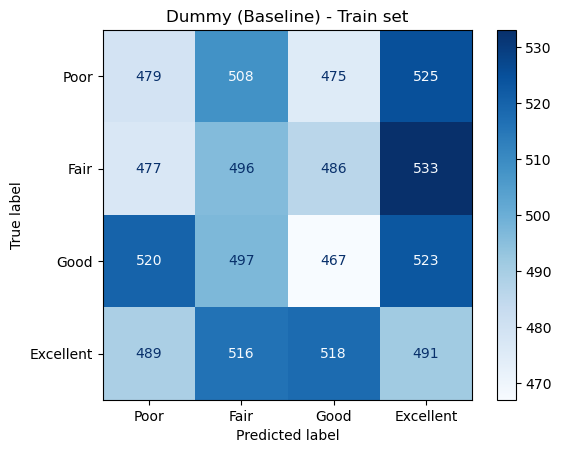

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.24      0.24      0.24      1987
        Fair       0.25      0.25      0.25      1992
        Good       0.24      0.23      0.24      2007
   Excellent       0.24      0.24      0.24      2014

    accuracy                           0.24      8000
   macro avg       0.24      0.24      0.24      8000
weighted avg       0.24      0.24      0.24      8000



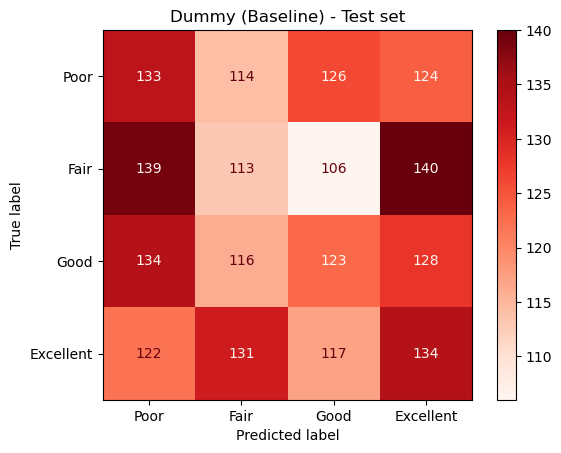

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.25      0.27      0.26       497
        Fair       0.24      0.23      0.23       498
        Good       0.26      0.25      0.25       501
   Excellent       0.25      0.27      0.26       504

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000

=== Summary: Dummy (Baseline) ===
Macro recall  - train: 0.242 | test: 0.251 | gap: -0.010
'Poor' recall - train: 0.241 | test: 0.268
Test accuracy : 0.252 vs random guess 0.250 (binomial test p = 0.447)
95% CI of test accuracy: 0.233 - 0.271
Overfit       : no (recall gap <= 0.10)
Real signal   : NO (not better than random guessing)


In [75]:
evaluate_model('Dummy (Baseline)', y_pred_train_mDummy, y_pred_test_mDummy)

The Dummy Classifier guesses according to the class proportions without using any feature. Its test macro recall (0.251) and accuracy (0.252) show what "no learning" looks like: about 0.25 with four balanced classes. This is the **lower bound** every other model must beat.

## Logistic Regression

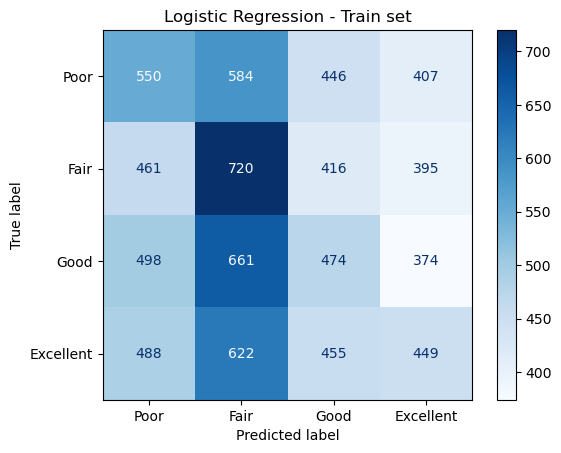

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.28      0.28      0.28      1987
        Fair       0.28      0.36      0.31      1992
        Good       0.26      0.24      0.25      2007
   Excellent       0.28      0.22      0.25      2014

    accuracy                           0.27      8000
   macro avg       0.27      0.27      0.27      8000
weighted avg       0.27      0.27      0.27      8000



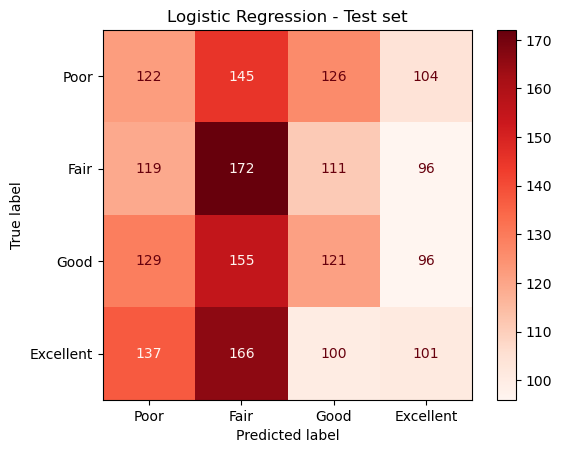

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.24      0.25      0.24       497
        Fair       0.27      0.35      0.30       498
        Good       0.26      0.24      0.25       501
   Excellent       0.25      0.20      0.22       504

    accuracy                           0.26      2000
   macro avg       0.26      0.26      0.26      2000
weighted avg       0.26      0.26      0.26      2000

=== Summary: Logistic Regression ===
Macro recall  - train: 0.274 | test: 0.258 | gap: 0.016
'Poor' recall - train: 0.277 | test: 0.245
Test accuracy : 0.258 vs random guess 0.250 (binomial test p = 0.211)
95% CI of test accuracy: 0.239 - 0.278
Overfit       : no (recall gap <= 0.10)
Real signal   : NO (not better than random guessing)


In [76]:
evaluate_model('Logistic Regression', y_pred_train_mLR, y_pred_test_mLR)

Logistic Regression is the simplest model and the hardest to overfit. Train and test macro recall are close (0.274 vs 0.258, gap 0.016), so it does not overfit, but both are only slightly above 0.25. Its test accuracy of 0.258 is not significantly better than random guessing (p = 0.211, and the 95% confidence interval 0.239-0.278 contains 0.25).

## KNN

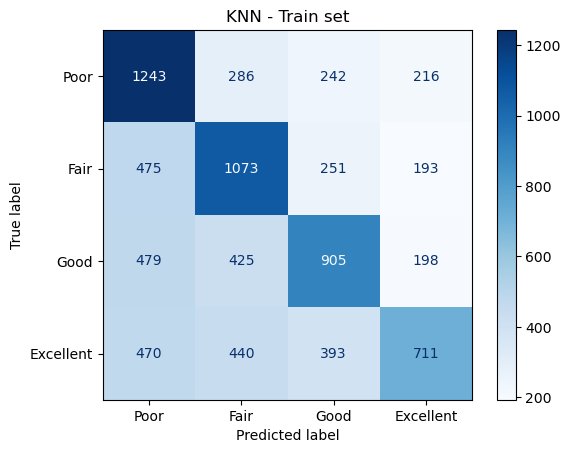

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.47      0.63      0.53      1987
        Fair       0.48      0.54      0.51      1992
        Good       0.51      0.45      0.48      2007
   Excellent       0.54      0.35      0.43      2014

    accuracy                           0.49      8000
   macro avg       0.50      0.49      0.49      8000
weighted avg       0.50      0.49      0.49      8000



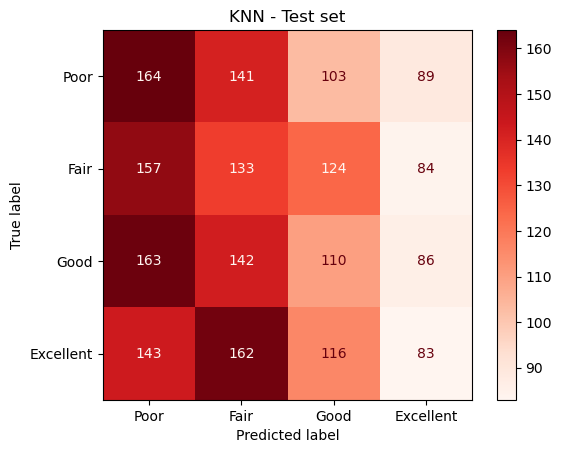

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.26      0.33      0.29       497
        Fair       0.23      0.27      0.25       498
        Good       0.24      0.22      0.23       501
   Excellent       0.24      0.16      0.20       504

    accuracy                           0.24      2000
   macro avg       0.24      0.25      0.24      2000
weighted avg       0.24      0.24      0.24      2000

=== Summary: KNN ===
Macro recall  - train: 0.492 | test: 0.245 | gap: 0.247
'Poor' recall - train: 0.626 | test: 0.330
Test accuracy : 0.245 vs random guess 0.250 (binomial test p = 0.705)
95% CI of test accuracy: 0.227 - 0.264
Overfit       : YES (recall gap > 0.10)
Real signal   : NO (not better than random guessing)


In [77]:
evaluate_model('KNN', y_pred_train_mKNN, y_pred_test_mKNN)

KNN stores the entire training set, so every training point is its own neighbor and the train score is inflated: train macro recall is 0.492 against 0.245 on the test set (gap 0.247). The test accuracy of 0.245 is no better than random guessing (p = 0.705).

## SVM

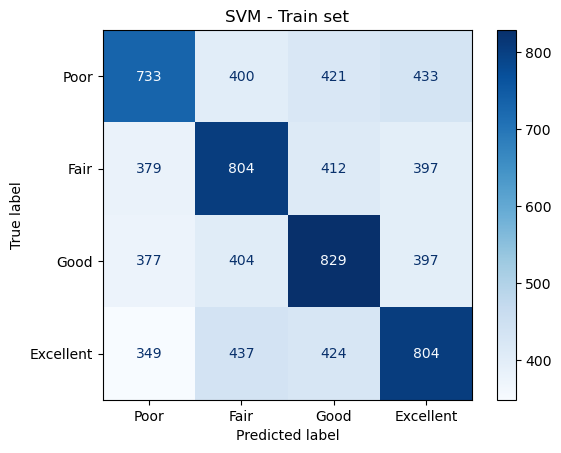

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.40      0.37      0.38      1987
        Fair       0.39      0.40      0.40      1992
        Good       0.40      0.41      0.41      2007
   Excellent       0.40      0.40      0.40      2014

    accuracy                           0.40      8000
   macro avg       0.40      0.40      0.40      8000
weighted avg       0.40      0.40      0.40      8000



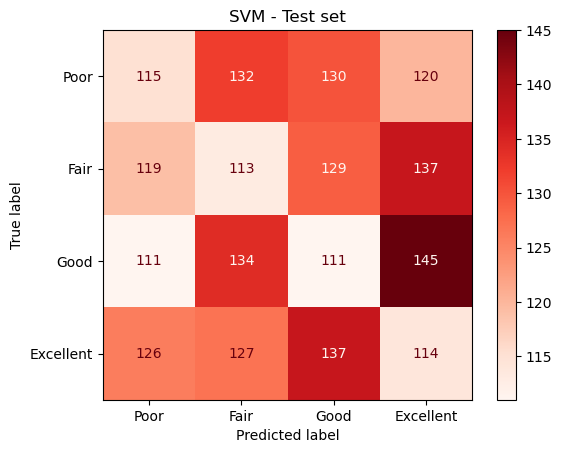

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.24      0.23      0.24       497
        Fair       0.22      0.23      0.23       498
        Good       0.22      0.22      0.22       501
   Excellent       0.22      0.23      0.22       504

    accuracy                           0.23      2000
   macro avg       0.23      0.23      0.23      2000
weighted avg       0.23      0.23      0.23      2000

=== Summary: SVM ===
Macro recall  - train: 0.396 | test: 0.227 | gap: 0.170
'Poor' recall - train: 0.369 | test: 0.231
Test accuracy : 0.227 vs random guess 0.250 (binomial test p = 0.993)
95% CI of test accuracy: 0.209 - 0.245
Overfit       : YES (recall gap > 0.10)
Real signal   : NO (not better than random guessing)


In [78]:
evaluate_model('SVM', y_pred_train_mSVM, y_pred_test_mSVM)

The SVM with the default RBF kernel fits part of the noise in the training data (train macro recall 0.396, test 0.227, gap 0.170). Its test accuracy (0.226, 95% confidence interval 0.209-0.245) is even slightly below the 0.25 expected from guessing, so what it learned from the training set does not generalize.

## Decision Tree

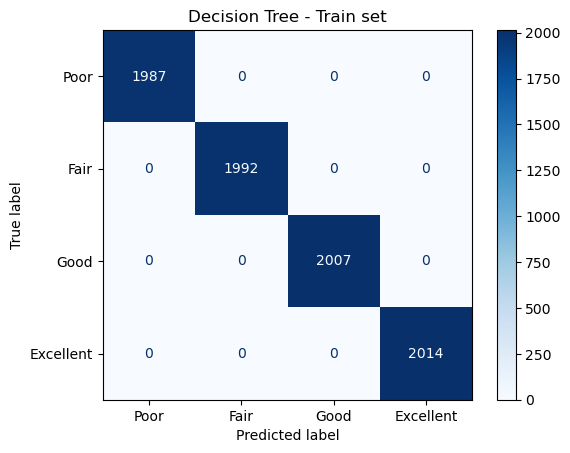

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00      1987
        Fair       1.00      1.00      1.00      1992
        Good       1.00      1.00      1.00      2007
   Excellent       1.00      1.00      1.00      2014

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



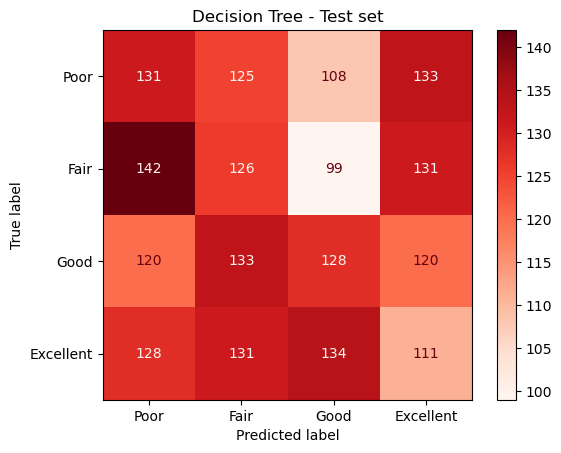

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.25      0.26      0.26       497
        Fair       0.24      0.25      0.25       498
        Good       0.27      0.26      0.26       501
   Excellent       0.22      0.22      0.22       504

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000

=== Summary: Decision Tree ===
Macro recall  - train: 1.000 | test: 0.248 | gap: 0.752
'Poor' recall - train: 1.000 | test: 0.264
Test accuracy : 0.248 vs random guess 0.250 (binomial test p = 0.590)
95% CI of test accuracy: 0.230 - 0.267
Overfit       : YES (recall gap > 0.10)
Real signal   : NO (not better than random guessing)


In [79]:
evaluate_model('Decision Tree', y_pred_train_mDTC, y_pred_test_mDTC)

A Decision Tree without a depth limit grows until every leaf is pure, so the train score is 1.00 while the test score is only about 0.25. The tree memorized the training data (overfitting) instead of finding a pattern that holds in general.

## Random Forest

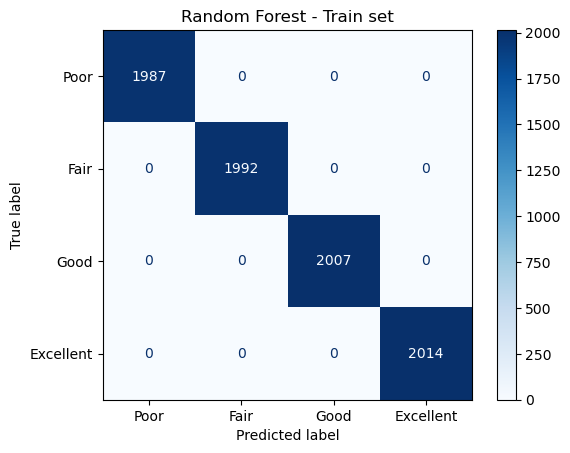

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00      1987
        Fair       1.00      1.00      1.00      1992
        Good       1.00      1.00      1.00      2007
   Excellent       1.00      1.00      1.00      2014

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



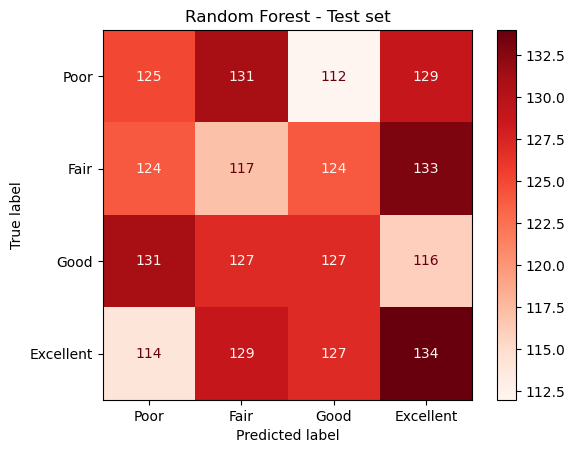

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.25      0.25      0.25       497
        Fair       0.23      0.23      0.23       498
        Good       0.26      0.25      0.26       501
   Excellent       0.26      0.27      0.26       504

    accuracy                           0.25      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.25      0.25      0.25      2000

=== Summary: Random Forest ===
Macro recall  - train: 1.000 | test: 0.251 | gap: 0.749
'Poor' recall - train: 1.000 | test: 0.252
Test accuracy : 0.252 vs random guess 0.250 (binomial test p = 0.447)
95% CI of test accuracy: 0.233 - 0.271
Overfit       : YES (recall gap > 0.10)
Real signal   : NO (not better than random guessing)


In [80]:
evaluate_model('Random Forest', y_pred_train_mRF, y_pred_test_mRF)

The Random Forest also reaches 1.00 on the train set but only about 0.25 on the test set, so the ensemble does not help: there is no pattern to learn from the available features. This is consistent with the permutation importance, where every feature is below 0.01.

## XGBoost

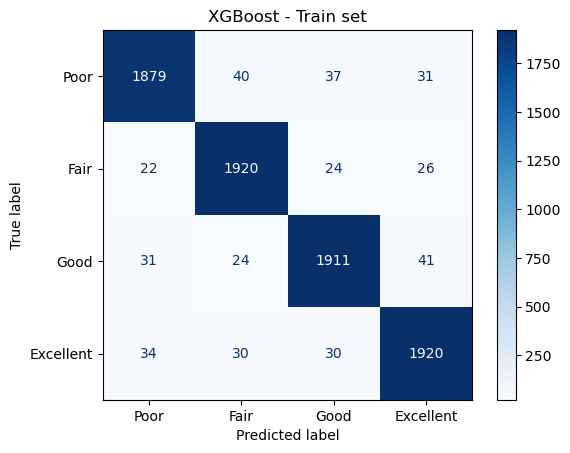

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.96      0.95      0.95      1987
        Fair       0.95      0.96      0.96      1992
        Good       0.95      0.95      0.95      2007
   Excellent       0.95      0.95      0.95      2014

    accuracy                           0.95      8000
   macro avg       0.95      0.95      0.95      8000
weighted avg       0.95      0.95      0.95      8000



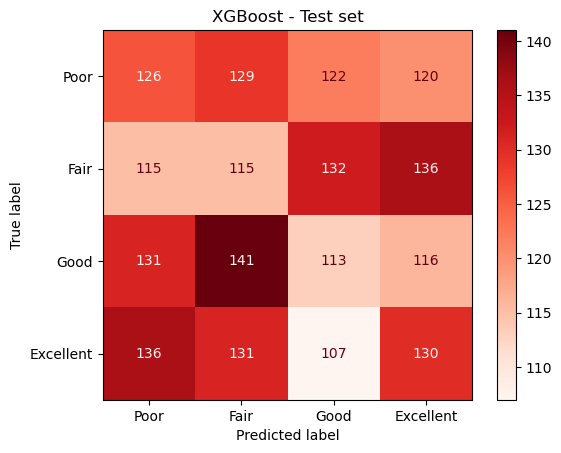

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.25      0.25      0.25       497
        Fair       0.22      0.23      0.23       498
        Good       0.24      0.23      0.23       501
   Excellent       0.26      0.26      0.26       504

    accuracy                           0.24      2000
   macro avg       0.24      0.24      0.24      2000
weighted avg       0.24      0.24      0.24      2000

=== Summary: XGBoost ===
Macro recall  - train: 0.954 | test: 0.242 | gap: 0.712
'Poor' recall - train: 0.946 | test: 0.254
Test accuracy : 0.242 vs random guess 0.250 (binomial test p = 0.803)
95% CI of test accuracy: 0.224 - 0.261
Overfit       : YES (recall gap > 0.10)
Real signal   : NO (not better than random guessing)


In [81]:
evaluate_model('XGBoost', y_pred_train_mXGB, y_pred_test_mXGB)

XGBoost fits the training data very closely (train macro recall 0.954) but its test macro recall is only 0.242 (gap 0.712, p = 0.803 against random guessing). It is a clear case of overfitting without any generalization.

## MLP (Neural Network)

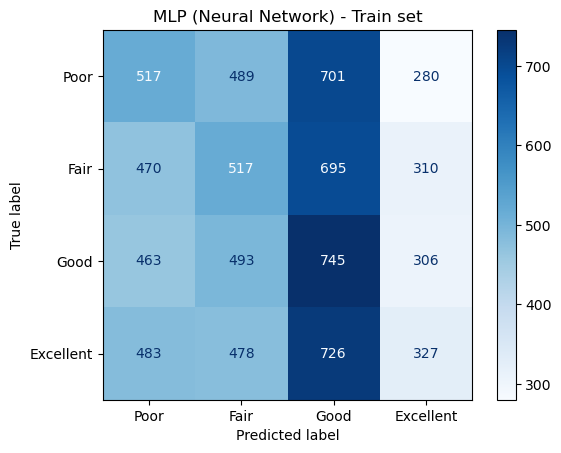

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.27      0.26      0.26      1987
        Fair       0.26      0.26      0.26      1992
        Good       0.26      0.37      0.31      2007
   Excellent       0.27      0.16      0.20      2014

    accuracy                           0.26      8000
   macro avg       0.26      0.26      0.26      8000
weighted avg       0.26      0.26      0.26      8000



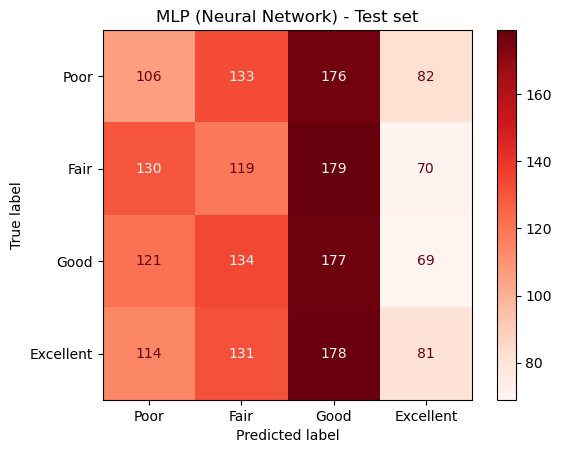

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.23      0.21      0.22       497
        Fair       0.23      0.24      0.23       498
        Good       0.25      0.35      0.29       501
   Excellent       0.27      0.16      0.20       504

    accuracy                           0.24      2000
   macro avg       0.24      0.24      0.24      2000
weighted avg       0.24      0.24      0.24      2000

=== Summary: MLP (Neural Network) ===
Macro recall  - train: 0.263 | test: 0.242 | gap: 0.022
'Poor' recall - train: 0.260 | test: 0.213
Test accuracy : 0.241 vs random guess 0.250 (binomial test p = 0.817)
95% CI of test accuracy: 0.223 - 0.261
Overfit       : no (recall gap <= 0.10)
Real signal   : NO (not better than random guessing)


In [82]:
evaluate_model('MLP (Neural Network)', y_pred_train_mMLP, y_pred_test_mMLP)

The MLP uses early stopping, so it is more controlled than the tree models (train 0.263, test 0.242, gap 0.022) and does not overfit. However, its test accuracy of 0.241 is still not better than random guessing (p = 0.817): the extra flexibility does not help because there is no pattern to learn.

## Model Comparison Summary

In [83]:
summary = pd.DataFrame(eval_results).set_index('Model')
summary = summary.sort_values('Test Recall Macro', ascending=False)

# Multiple-comparison correction: with many models tested at once, the chance that one looks
# "significant" purely by luck grows. The threshold is tightened (Bonferroni) by the number of non-baseline models.
n_models = int((~summary.index.str.contains('Dummy')).sum())
alpha_bonf = 0.05 / n_models
summary['Significant (Bonferroni)'] = summary['p-value vs random'] < alpha_bonf
print(f"Bonferroni threshold for {n_models} models: p < {alpha_bonf:.4f}")
summary.round(3)

Bonferroni threshold for 7 models: p < 0.0071


,Train Accuracy,Test Accuracy,Train Recall Macro,Test Recall Macro,Test F1 Macro,CV Recall Macro (mean),CV Recall Macro (std),Test Acc CI low,Test Acc CI high,Recall Gap,p-value vs random,Overfit,Significant (p<0.05),Significant (Bonferroni)
Model,,,,,,,,,,,,,,
Logistic Regression,0.274,0.258,0.274,0.258,0.256,0.254,0.002,0.239,0.278,0.016,0.211,False,False,False
Dummy (Baseline),0.242,0.252,0.242,0.251,0.251,0.252,0.012,0.233,0.271,-0.010,0.447,False,False,False
Random Forest,1.000,0.252,1.000,0.251,0.251,0.249,0.007,0.233,0.271,0.749,0.447,True,False,False
Decision Tree,1.000,0.248,1.000,0.248,0.248,0.249,0.008,0.230,0.267,0.752,0.590,True,False,False
KNN,0.492,0.245,0.492,0.245,0.241,0.251,0.003,0.227,0.264,0.247,0.705,True,False,False
XGBoost,0.954,0.242,0.954,0.242,0.242,0.248,0.010,0.224,0.261,0.712,0.803,True,False,False
MLP (Neural Network),0.263,0.242,0.263,0.242,0.237,0.251,0.011,0.223,0.261,0.022,0.817,False,False,False
SVM,0.396,0.226,0.396,0.227,0.227,0.245,0.011,0.209,0.245,0.170,0.993,True,False,False


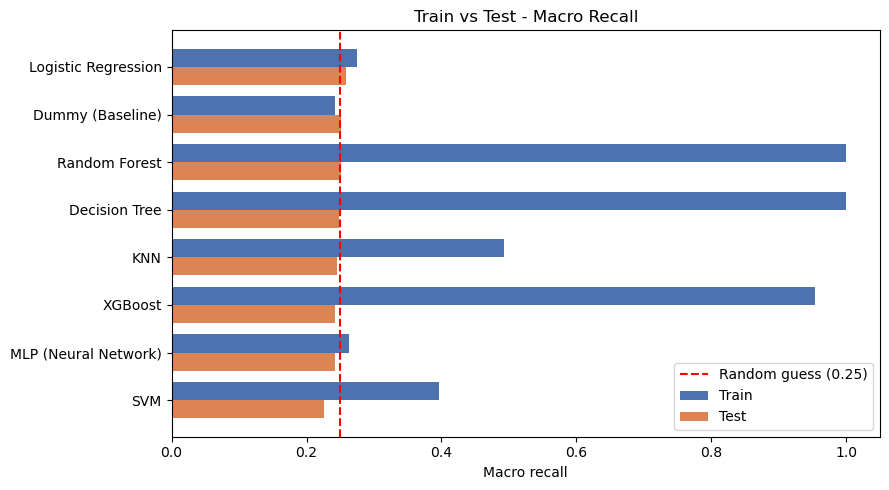

In [84]:
# Visualization: macro recall, train vs test
d = summary.sort_values('Test Recall Macro')
y_pos = np.arange(len(d))
h = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y_pos + h/2, d['Train Recall Macro'], h, label='Train', color='#4C72B0')
ax.barh(y_pos - h/2, d['Test Recall Macro'], h, label='Test', color='#DD8452')
ax.axvline(0.25, color='red', ls='--', label='Random guess (0.25)')
ax.set_yticks(y_pos)
ax.set_yticklabels(d.index)
ax.set_xlabel('Macro recall')
ax.set_title('Train vs Test - Macro Recall')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [85]:
# Automatic conclusion (among the non-baseline models)
candidates = summary[~summary.index.str.contains('Dummy')]
best = candidates['Test Recall Macro'].idxmax()
row = candidates.loc[best]

print(f"Model with the highest test macro recall: {best}")
print(f"Test macro recall = {row['Test Recall Macro']:.3f} | test accuracy = {row['Test Accuracy']:.3f} | random guess = 0.250")
print(f"Significantly above random guessing (p<0.05): {bool(row['Significant (p<0.05)'])}")
print(f"Significant after Bonferroni correction     : {bool(row['Significant (Bonferroni)'])}")
print(f"95% CI of this model's test accuracy: {row['Test Acc CI low']:.3f} - {row['Test Acc CI high']:.3f} (random guess = 0.250)")
print(f"Non-baseline models that are significant: {int(candidates['Significant (p<0.05)'].sum())} of {len(candidates)}")
print(f"Non-baseline models that overfit        : {int(candidates['Overfit'].sum())} of {len(candidates)}")

Model with the highest test macro recall: Logistic Regression
Test macro recall = 0.258 | test accuracy = 0.258 | random guess = 0.250
Significantly above random guessing (p<0.05): False
Significant after Bonferroni correction     : False
95% CI of this model's test accuracy: 0.239 - 0.278 (random guess = 0.250)
Non-baseline models that are significant: 0 of 7
Non-baseline models that overfit        : 5 of 7


**Summary:**

* The test macro recall of all seven models is between 0.227 and 0.258, which is the range expected from random guessing with four balanced classes (0.25). The Dummy baseline scores 0.251.
* No model is significantly better than random guessing: the smallest p-value is 0.211 (Logistic Regression), far from 0.05, and none passes the stricter Bonferroni threshold (0.0071).
* Five of the seven models overfit (recall gap above 0.10): KNN, SVM, Decision Tree, Random Forest, and XGBoost. The Decision Tree and Random Forest reach 1.00 on the train set while staying at about 0.25 on the test set, so a high train score says nothing about quality here.
* Cross-validation gives the same picture: the CV macro recall of every model is between 0.245 and 0.254, and the Dummy baseline (0.252) is inside that range.
* Because the best non-baseline model is not distinguishable from the baseline, the finding of this comparison is that the available features do not predict `Mental_Health_Status`. That is a valid result, not a failure of a particular algorithm.
* Model selection for hyperparameter tuning relies on the **cross-validation recall (CV)**, not on the test score, because the test set should be used only for the final evaluation.

# Hyperparameter Tuning Best Model

The model is selected with the **cross-validation macro recall on the training set**, not with the test score. Among the non-baseline models, Logistic Regression has the highest CV macro recall (0.254, std 0.002); it also has the highest test macro recall (0.258) and a very small train-test gap (0.016), so it is the best model of this comparison and the one that is tuned. Two points must be kept in mind: its CV score is only 0.002 above the Dummy baseline (0.252, std 0.012), which is well inside the noise, and the other models have lower CV scores (KNN 0.251, MLP 0.251, Decision Tree 0.249, Random Forest 0.249, XGBoost 0.248, SVM 0.245).

### Finding Best Parameter

In [86]:
# hyperparameter search space for tuning
# C is the inverse of the regularization strength (small C = stronger regularization)
grid_search_params = {'LR__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search_params

{'LR__C': [0.001, 0.01, 0.1, 1, 10, 100]}

- `C` controls the regularization strength of Logistic Regression: a small `C` means strong regularization (a simpler model), a large `C` means weak regularization.
- Grid Search is used because the search space is small, so every value can be tried with the same Stratified 5-Fold scheme and `recall_macro` scoring as in the model comparison.

In [87]:
# tuning with grid search
LR_gridcv = GridSearchCV(estimator = mModelLR,
                         param_grid = grid_search_params,
                         cv = cv_strategy,
                         scoring = 'recall_macro',
                         n_jobs = -1)

In [88]:
# fit the grid search on the training data
LR_gridcv.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('PreprocessingPipe',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'Technology_Usage_Hours',
                                                                          'Social_Media_Usage_Hours',
                                                                          'Gaming_Hours',
                                                                          'Screen_Time_Hours',
                                                                          'Sleep_Hours',
                                                                          'Physical_Activity_Hours']),
                                                                        ('nom',
                                                                         OneHotEncoder(drop='first',
                                                                                       hand...'ignore'),
                                                                         ['Gender',
                                                                          'Support_Systems_Access',
                                                                          'Online_Support_Usage']),
                                                                        ('ord',
                                                                         OrdinalEncoder(categories=[['Low',
                                                                                                     'Medium',
                                                                                                     'High'],
                                                                                                    ['Positive',
                                                                                                     'Neutral',
                                                                                                     'Negative']]),
                                                                         ['Stress_Level',
                                                                          'Work_Environment_Impact'])])),
                                       ('LR',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'LR__C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='recall_macro')

In [89]:
# best parameters found and the score of every candidate
best_C = LR_gridcv.best_params_['LR__C']
print('Best parameters:', LR_gridcv.best_params_)

(pd.DataFrame(LR_gridcv.cv_results_)[['param_LR__C', 'mean_test_score', 'std_test_score', 'rank_test_score']]
   .rename(columns={'param_LR__C': 'C', 'mean_test_score': 'CV macro recall (mean)',
                    'std_test_score': 'CV macro recall (std)', 'rank_test_score': 'Rank'})
   .round(4))

Best parameters: {'LR__C': 0.01}


,C,CV macro recall (mean),CV macro recall (std),Rank
0,0.001,0.2524,0.0027,6
1,0.010,0.2555,0.0030,1
2,0.100,0.2536,0.0022,5
3,1.000,0.2539,0.0024,2
4,10.000,0.2538,0.0023,3
5,100.000,0.2538,0.0023,3


The CV macro recall of all `C` values lies between 0.252 and 0.256, and the difference between the best and the worst value is smaller than the fold-to-fold standard deviation (about 0.002-0.003). The "best" `C` is therefore only marginally better than the others, and the search cannot be expected to produce a meaningfully better model.

## Create Pipeline with Hyperparameter

In [90]:
# Pipeline with the best hyperparameter found by the grid search
ModelInf = LogisticRegression(C = best_C, max_iter = 1000, random_state = 42)

InfLR = Pipeline([('PreprocessingPipe', clone(preprocessor)),
                  ('LR', ModelInf)])

The pipeline includes feature scaling, feature encoding, and the model. The scaling method is `StandardScaler` and the encoding method is `OneHotEncoder` (nominal columns) together with `OrdinalEncoder` (ordinal columns). `StandardScaler` is used because the numerical columns are symmetric (skewness close to 0). `OneHotEncoder` is used because the nominal columns have no natural order. Scaling and encoding are applied with `ColumnTransformer` so the data can be fed into the machine learning model.

The variable `InfLR` stores the pipeline for the Logistic Regression model with the scaled and encoded columns. The hyperparameter used is the value of `C` found by the grid search (`C = 0.01`).

## Training Best Model

In [91]:
# train the model
InfLR.fit(X_train, y_train)

Pipeline(steps=[('PreprocessingPipe',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Technology_Usage_Hours',
                                                   'Social_Media_Usage_Hours',
                                                   'Gaming_Hours',
                                                   'Screen_Time_Hours',
                                                   'Sleep_Hours',
                                                   'Physical_Activity_Hours']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Support_Systems_Access',
                                                   'Online_Support_Usage']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Positive',
                                                                              'Neutral',
                                                                              'Negative']]),
                                                  ['Stress_Level',
                                                   'Work_Environment_Impact'])])),
                ('LR',
                 LogisticRegression(C=0.01, max_iter=1000, random_state=42))])

## Hyperparameter Tuning - Evaluation

In [92]:
# predictions on the train set
y_pred_train_tune = InfLR.predict(X_train)

# predictions on the test set
y_pred_test_tune = InfLR.predict(X_test)

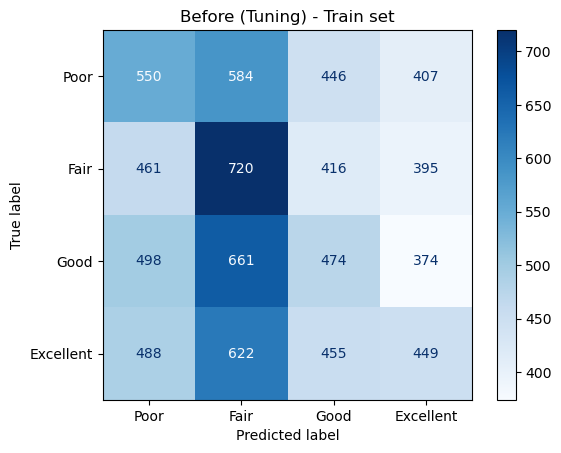

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.28      0.28      0.28      1987
        Fair       0.28      0.36      0.31      1992
        Good       0.26      0.24      0.25      2007
   Excellent       0.28      0.22      0.25      2014

    accuracy                           0.27      8000
   macro avg       0.27      0.27      0.27      8000
weighted avg       0.27      0.27      0.27      8000



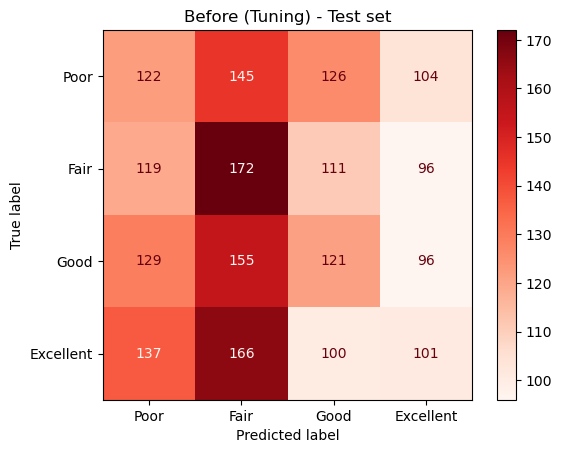

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.24      0.25      0.24       497
        Fair       0.27      0.35      0.30       498
        Good       0.26      0.24      0.25       501
   Excellent       0.25      0.20      0.22       504

    accuracy                           0.26      2000
   macro avg       0.26      0.26      0.26      2000
weighted avg       0.26      0.26      0.26      2000



In [93]:
# Helper: confusion matrices and classification reports of the train and test set
def show_report(stage, y_pred_train, y_pred_test):
    for split, y_true, y_pred, cmap in [('Train', y_train, y_pred_train, plt.cm.Blues),
                                        ('Test', y_test, y_pred_test, plt.cm.Reds)]:
        CM = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=labels).plot(cmap=cmap)
        plt.title(f"{stage} - {split} set")
        plt.show()

        print(f"Classification Report - {split} Set:")
        print(classification_report(y_true, y_pred, target_names=labels))


# Before tuning: Logistic Regression with the default C = 1.0
show_report('Before (Tuning)', y_pred_train_mLR, y_pred_test_mLR)

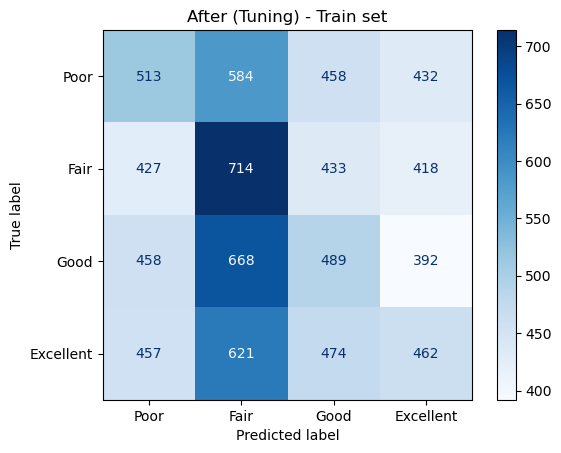

Classification Report - Train Set:
              precision    recall  f1-score   support

        Poor       0.28      0.26      0.27      1987
        Fair       0.28      0.36      0.31      1992
        Good       0.26      0.24      0.25      2007
   Excellent       0.27      0.23      0.25      2014

    accuracy                           0.27      8000
   macro avg       0.27      0.27      0.27      8000
weighted avg       0.27      0.27      0.27      8000



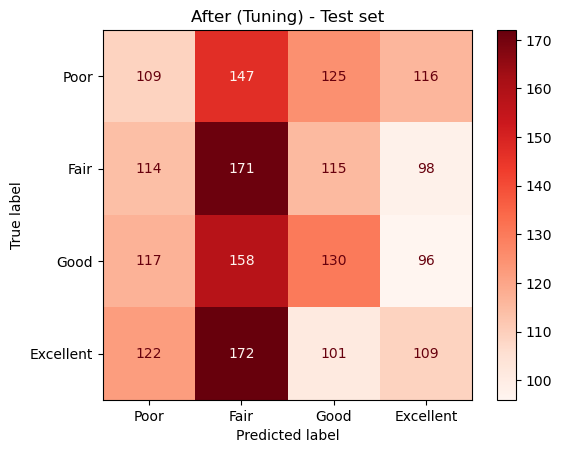

Classification Report - Test Set:
              precision    recall  f1-score   support

        Poor       0.24      0.22      0.23       497
        Fair       0.26      0.34      0.30       498
        Good       0.28      0.26      0.27       501
   Excellent       0.26      0.22      0.24       504

    accuracy                           0.26      2000
   macro avg       0.26      0.26      0.26      2000
weighted avg       0.26      0.26      0.26      2000



In [94]:
# After tuning: Logistic Regression with the best C
show_report('After (Tuning)', y_pred_train_tune, y_pred_test_tune)

In [95]:
# Compare before and after tuning in one table
rows = []
for stage, p_train, p_test, cv_mean in [
        ('Before tuning (C = 1)', y_pred_train_mLR, y_pred_test_mLR, cv_results['Logistic Regression'].mean()),
        (f'After tuning (C = {best_C})', y_pred_train_tune, y_pred_test_tune, LR_gridcv.best_score_)]:

    n_correct = int((np.asarray(p_test) == np.asarray(y_test)).sum())
    ci = binomtest(n_correct, len(y_test), 0.25).proportion_ci(confidence_level=0.95, method='wilson')

    rows.append({'Stage': stage,
                 'CV Recall Macro': cv_mean,
                 'Train Recall Macro': recall_score(y_train, p_train, average='macro'),
                 'Test Recall Macro': recall_score(y_test, p_test, average='macro'),
                 'Test Accuracy': n_correct / len(y_test),
                 'Test Acc CI low': ci.low,
                 'Test Acc CI high': ci.high,
                 'p-value vs random': binomtest(n_correct, len(y_test), 0.25, alternative='greater').pvalue})

pd.DataFrame(rows).set_index('Stage').round(3)

,CV Recall Macro,Train Recall Macro,Test Recall Macro,Test Accuracy,Test Acc CI low,Test Acc CI high,p-value vs random
Stage,,,,,,,
Before tuning (C = 1),0.254,0.274,0.258,0.258,0.239,0.278,0.211
After tuning (C = 0.01),0.255,0.272,0.260,0.260,0.241,0.279,0.170


Based on the confusion matrices, classification reports, and the comparison table above:

- Tuning changes almost nothing: the CV macro recall moves from 0.254 to 0.255 and the test macro recall from 0.258 to 0.260, differences that are smaller than the fold-to-fold standard deviation.
- The tuned model is not better than random guessing: the test accuracy is 0.260 with a 95% confidence interval of 0.241-0.279, which contains 0.25 (p = 0.170).
- The model does not overfit (train macro recall 0.272 vs test 0.260), but this is because it is a heavily regularized linear model that has found almost nothing, not because it generalizes well.
- For the class that matters most, **Poor**, the tuned model reaches a recall of only 0.22 and a precision of 0.24 on the test set. Both are at or below the 0.25 expected from guessing, so the model would miss about 78% of the respondents with a Poor status.

## Sanity Check - Would a Binary Target Help?

Merging the categories into two groups (Poor/Fair = 0 and Good/Excellent = 1) is a common idea when four classes are hard to separate. Here it is tested directly with the ROC-AUC (0.5 = random ranking, 1.0 = perfect ranking).

In [96]:
# Sanity check: does grouping the target into 2 classes make it learnable? (1 = Good/Excellent, 0 = Poor/Fair)
y_train_bin = (y_train >= 2).astype(int)
y_test_bin = (y_test >= 2).astype(int)

binary_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42)
}

rows = []
for name, model in binary_models.items():
    pipe = Pipeline([('PreprocessingPipe', clone(preprocessor)), ('Model', model)])
    cv_auc = cross_val_score(pipe, X_train, y_train_bin, cv=cv_strategy, scoring='roc_auc')
    pipe.fit(X_train, y_train_bin)
    rows.append({'Model': name,
                 'CV ROC-AUC (mean)': cv_auc.mean(),
                 'Test ROC-AUC': roc_auc_score(y_test_bin, pipe.predict_proba(X_test)[:, 1]),
                 'Test Accuracy': accuracy_score(y_test_bin, pipe.predict(X_test))})

pd.DataFrame(rows).set_index('Model').round(3)

,CV ROC-AUC (mean),Test ROC-AUC,Test Accuracy
Model,,,
Logistic Regression,0.496,0.476,0.491
Random Forest,0.500,0.488,0.496


With two groups, the ROC-AUC is about 0.50 in cross-validation and 0.48-0.49 on the test set, and the accuracy is about 0.49 (random guessing gives 0.50). Grouping the categories therefore does **not** make the target learnable, which confirms that the problem is the information in the features and not the number of classes.

# x. Model Saving

In [97]:
# save the tuned Logistic Regression pipeline (preprocessing + model) to be used for inference
with open('model.pkl', 'wb') as file:
    pickle.dump(InfLR, file)

# Check: reload the file and confirm that it gives exactly the same predictions
with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print('The reloaded model reproduces the test predictions:', np.array_equal(loaded_model.predict(X_test), y_pred_test_tune))

The reloaded model reproduces the test predictions: True


The analysis below uses the predictions of the saved model (`InfLR`, the tuned Logistic Regression pipeline written to `model.pkl`). It focuses on the most costly kind of error in this table: respondents whose actual status is **Excellent** (class 3) but who were predicted as **Poor, Fair, or Good** (classes 0, 1, 2). To judge whether these errors concentrate in a particular group, the averages of the misclassified respondents per age group are compared with the average of **all** actual-Excellent respondents (red dashed line), and the number of misclassified respondents per age group is shown, because small groups give unstable averages.

# Model Analysis Train

In [98]:
# Age group function
def categorize_age(age):
    if 18 <= age <= 19:
        return "10's"
    elif 20 <= age <= 29:
        return "20's"
    elif 30 <= age <= 39:
        return "30's"
    elif 40 <= age <= 49:
        return "40's"
    elif 50 <= age <= 59:
        return "50's"
    elif 60 <= age <= 69:
        return "60's"
    else:
        return 'Other'


AgeOrder = ["10's", "20's", "30's", "40's", "50's", "60's"]
AnalysisColumns = ['Sleep_Hours', 'Physical_Activity_Hours', 'Gaming_Hours']


# Helper: bar chart of the average of a column per age group, with the average of all actual-Excellent respondents as reference
def plot_age_mean(errors, reference, col, palette):
    means = errors.groupby('AgeGroup')[col].mean().reindex(AgeOrder)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=means.index, y=means.values, hue=means.index, palette=palette, legend=False)
    ax.axhline(reference, color='red', linestyle='--', label=f'All actual-Excellent respondents ({reference:.2f}h)')

    for i, val in enumerate(means.values):
        if not pd.isna(val):
            ax.text(i, val + 0.05, f"Avg: {val:.1f}h", ha='center', va='bottom', fontsize=9, color='black', style='italic')

    ax.set_ylim(0, max(means.max(), reference) * 1.2)
    ax.set_title(f"Average {col} per Age Group (misclassified Excellent respondents)")
    ax.set_xlabel('Age Group')
    ax.set_ylabel(col.replace('_', ' '))
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


# Helper: printed summary of the findings, so the text always matches the charts
def summarize_errors(all_rows, errors, split_name):
    excellent = all_rows[all_rows['Actual'] == 3]

    print(f"{split_name}: {len(errors)} of {len(excellent)} actual-Excellent respondents ({len(errors) / len(excellent):.1%}) were predicted as Poor/Fair/Good")
    print("Misclassified respondents per age group:", errors['AgeGroup'].value_counts().reindex(AgeOrder).to_dict())
    print()
    for col in AnalysisColumns:
        means = errors.groupby('AgeGroup')[col].mean().reindex(AgeOrder)
        print(f"{col}: all Excellent = {excellent[col].mean():.2f}h | misclassified = {errors[col].mean():.2f}h")
        print(f"    by age group: highest = {means.idxmax()} ({means.max():.1f}h), lowest = {means.idxmin()} ({means.min():.1f}h), spread = {means.max() - means.min():.2f}h")

In [99]:
# Predictions come from the saved model (InfLR): features, actual class, and predicted class of the same train rows
MAtrain = X_train.reset_index(drop=True).copy()
MAtrain['Actual'] = y_train.values
MAtrain['Pred'] = y_pred_train_tune
MAtrain['AgeGroup'] = MAtrain['Age'].apply(categorize_age)
MAtrain

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred,AgeGroup
0,62,Female,11.43,3.96,3.67,12.60,High,7.87,2.90,Yes,Negative,Yes,2,2,60's
1,31,Other,8.53,2.29,1.27,8.13,High,6.89,8.45,Yes,Positive,Yes,3,3,30's
2,61,Female,4.26,3.23,0.43,10.24,Low,8.20,1.96,Yes,Positive,No,0,1,60's
3,42,Male,5.55,7.49,1.67,6.52,Low,5.12,0.15,Yes,Neutral,No,0,0,40's
4,28,Other,10.99,7.80,3.94,5.73,High,7.37,4.72,Yes,Neutral,Yes,0,0,20's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,40,Other,8.72,2.51,3.84,11.06,High,7.56,6.13,Yes,Negative,No,3,0,40's
7996,63,Male,5.81,1.44,1.76,1.05,Medium,5.86,8.40,Yes,Positive,Yes,2,0,60's
7997,28,Other,10.72,6.50,1.35,6.92,Low,6.40,7.64,Yes,Neutral,No,2,0,20's
7998,18,Female,10.00,1.02,3.32,9.27,Medium,4.88,4.43,No,Negative,Yes,2,3,10's


In [100]:
# Misclassified rows: actual Excellent (3) predicted as Poor (0), Fair (1), or Good (2)
MATrain = MAtrain[(MAtrain['Pred'].isin([0, 1, 2])) & (MAtrain['Actual'].isin([3]))].copy()
MATrain

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred,AgeGroup
6,29,Male,8.39,0.85,2.26,8.79,High,6.71,2.84,Yes,Negative,No,3,2,20's
13,31,Female,2.46,3.17,1.71,14.51,Low,7.19,3.82,No,Negative,No,3,1,30's
24,62,Other,3.20,2.76,1.74,10.09,Low,7.53,6.08,No,Negative,Yes,3,1,60's
26,47,Female,8.56,3.86,3.94,1.86,Medium,8.60,2.83,Yes,Negative,Yes,3,0,40's
41,56,Male,4.66,6.22,3.06,12.76,Low,7.50,1.07,Yes,Positive,Yes,3,0,50's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7975,50,Female,10.62,0.47,4.57,2.74,Low,7.02,7.71,No,Positive,No,3,0,50's
7976,53,Other,7.12,7.32,4.19,4.45,Medium,6.20,0.58,Yes,Negative,No,3,1,50's
7981,22,Female,10.23,7.93,1.11,7.57,Medium,5.18,9.29,Yes,Neutral,No,3,2,20's
7992,60,Female,3.09,1.52,0.42,4.24,Low,5.41,0.41,Yes,Positive,Yes,3,1,60's


In [101]:
MATrain.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1552.0,42.687500,13.994828,18.00,31.0000,44.000,55.0000,65.00
Technology_Usage_Hours,1552.0,6.350090,3.187653,1.00,3.5550,6.245,9.0600,11.98
Social_Media_Usage_Hours,1552.0,4.254401,2.252625,0.00,2.3600,4.370,6.1800,8.00
Gaming_Hours,1552.0,2.571005,1.442842,0.00,1.3775,2.560,3.8625,5.00
Screen_Time_Hours,1552.0,8.060251,4.101729,1.01,4.4900,7.870,11.8300,15.00
Sleep_Hours,1552.0,6.706688,1.431069,4.02,5.4900,6.850,7.9725,9.00
Physical_Activity_Hours,1552.0,4.530316,2.845644,0.00,2.0875,4.320,6.9200,9.99
Actual,1552.0,3.000000,0.000000,3.00,3.0000,3.000,3.0000,3.00
Pred,1552.0,1.010954,0.774686,0.00,0.0000,1.000,2.0000,2.00


## Average 'Sleep_Hours' per age group - Train set

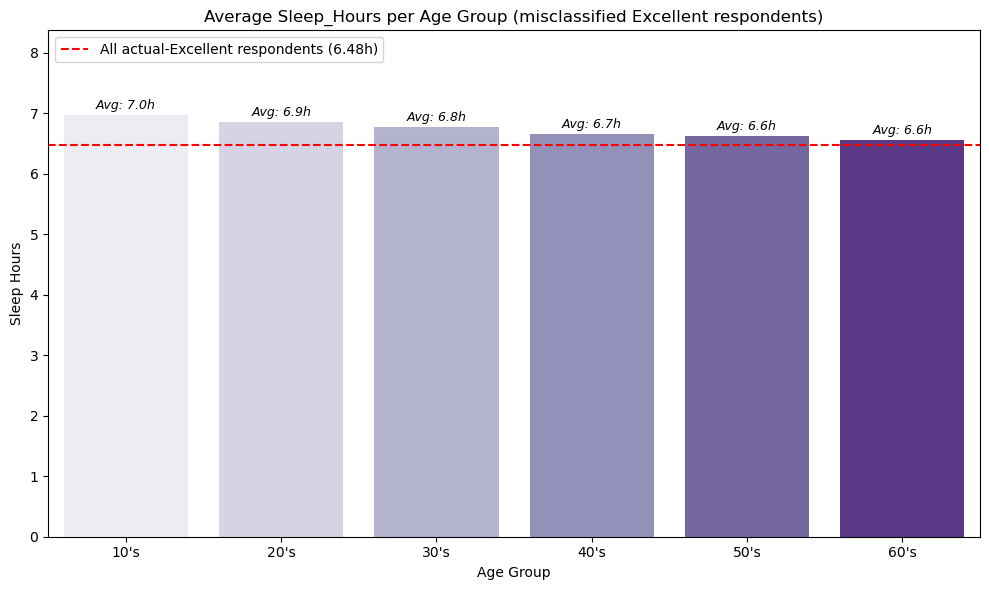

In [102]:
refTrain = MAtrain[MAtrain['Actual'] == 3]
plot_age_mean(MATrain, refTrain['Sleep_Hours'].mean(), 'Sleep_Hours', 'Purples')

## Average 'Physical_Activity_Hours' per age group - Train set

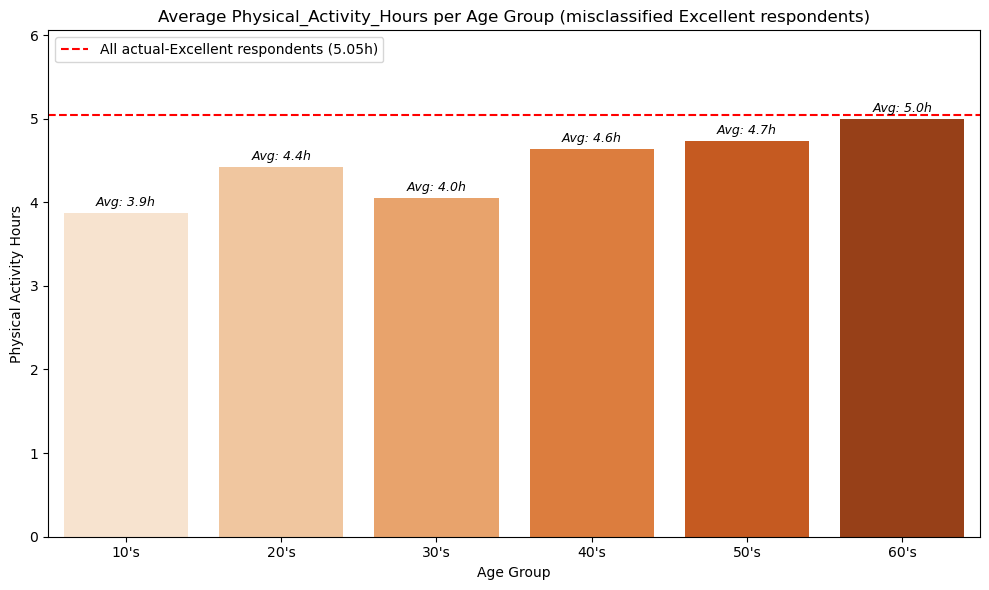

In [103]:
plot_age_mean(MATrain, refTrain['Physical_Activity_Hours'].mean(), 'Physical_Activity_Hours', 'Oranges')

## Average 'Gaming_Hours' per age group - Train set

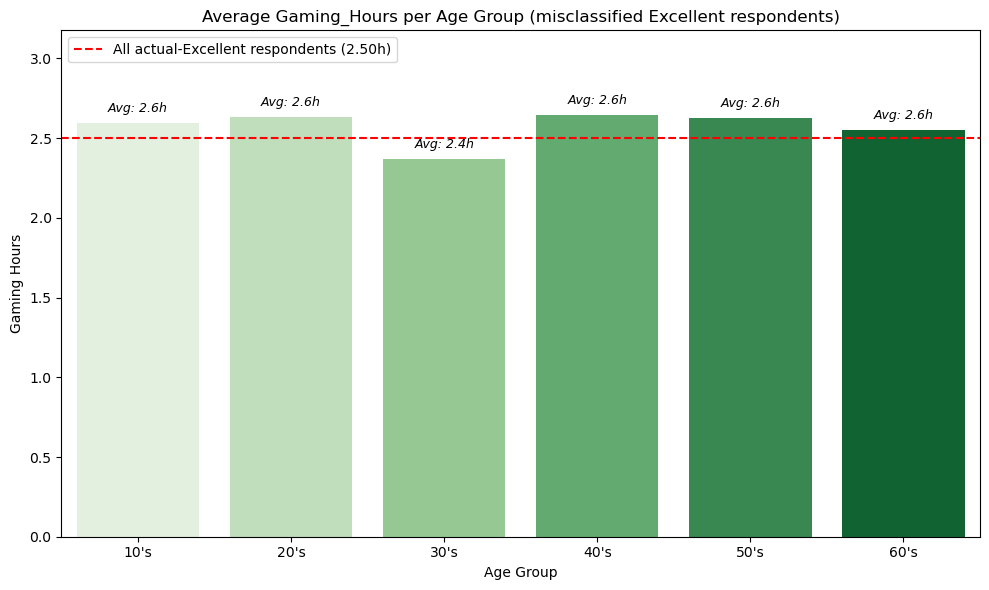

In [104]:
plot_age_mean(MATrain, refTrain['Gaming_Hours'].mean(), 'Gaming_Hours', 'Greens')

In [105]:
summarize_errors(MAtrain, MATrain, 'Train set')

Train set: 1552 of 2014 actual-Excellent respondents (77.1%) were predicted as Poor/Fair/Good
Misclassified respondents per age group: {"10's": 50, "20's": 309, "30's": 296, "40's": 309, "50's": 365, "60's": 223}

Sleep_Hours: all Excellent = 6.48h | misclassified = 6.71h
    by age group: highest = 10's (7.0h), lowest = 60's (6.6h), spread = 0.42h
Physical_Activity_Hours: all Excellent = 5.05h | misclassified = 4.53h
    by age group: highest = 60's (5.0h), lowest = 10's (3.9h), spread = 1.13h
Gaming_Hours: all Excellent = 2.50h | misclassified = 2.57h
    by age group: highest = 40's (2.6h), lowest = 30's (2.4h), spread = 0.28h


On the Train set, 1,552 of the 2,014 respondents whose actual status is **Excellent** (77.1%) were predicted as Poor, Fair, or Good. This is the same as the Excellent recall of 0.23 in the classification report, and it is what random guessing would give (75%).

Among these misclassified respondents:

- **'Sleep_Hours'**: the average is 6.71 hours (all Excellent respondents: 6.48). The highest age group is the **10's** (7.0 hours, only 50 respondents) and the lowest the 60's (6.6 hours).
- **'Physical_Activity_Hours'**: the average is 4.53 hours (all Excellent respondents: 5.05). The highest age group is the **60's** (5.0 hours) and the lowest the 10's (3.9 hours).
- **'Gaming_Hours'**: the average is 2.57 hours (all Excellent respondents: 2.50). The highest age group is the **40's** (2.6 hours) and the lowest the 30's (2.4 hours), a spread of only 0.28 hour.

Compared with all Excellent respondents, the misclassified ones sleep a little more and are less physically active. This only reflects how the model splits respondents (it labels people with more sleep and less activity as non-Excellent), not a real relationship: the EDA and the feature tests found no association between these variables and `Mental_Health_Status`. The errors are spread over all age groups, and the age groups with the highest and lowest averages are not the same as on the Test set (below), so there is no stable age pattern.

# Model Analysis Test

In [106]:
# Predictions come from the saved model (InfLR): features, actual class, and predicted class of the same test rows
MAtest = X_test.reset_index(drop=True).copy()
MAtest['Actual'] = y_test.values
MAtest['Pred'] = y_pred_test_tune
MAtest['AgeGroup'] = MAtest['Age'].apply(categorize_age)
MAtest

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred,AgeGroup
0,62,Other,7.81,3.81,0.98,14.48,Low,4.22,7.07,No,Positive,Yes,2,1,60's
1,41,Male,2.47,4.95,0.19,2.76,High,8.55,6.00,No,Neutral,Yes,3,1,40's
2,58,Female,6.78,2.66,2.12,10.43,Medium,7.15,1.92,Yes,Negative,No,2,2,50's
3,27,Male,1.94,1.48,4.14,9.00,High,4.23,1.19,No,Negative,No,0,2,20's
4,25,Other,8.35,4.56,1.02,10.42,Medium,6.47,9.83,Yes,Positive,No,0,3,20's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,33,Male,2.72,3.03,4.63,3.86,Low,5.21,7.81,Yes,Negative,Yes,0,0,30's
1996,46,Female,10.57,5.20,3.53,7.78,Low,5.53,6.09,Yes,Negative,Yes,0,0,40's
1997,47,Other,10.13,0.43,4.34,8.10,Low,5.81,6.01,No,Positive,Yes,3,3,40's
1998,53,Other,5.28,1.38,0.07,14.36,Low,4.55,5.53,No,Negative,No,1,1,50's


In [107]:
# Misclassified rows: actual Excellent (3) predicted as Poor (0), Fair (1), or Good (2)
MATest = MAtest[(MAtest['Pred'].isin([0, 1, 2])) & (MAtest['Actual'].isin([3]))].copy()
MATest

,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Actual,Pred,AgeGroup
1,41,Male,2.47,4.95,0.19,2.76,High,8.55,6.00,No,Neutral,Yes,3,1,40's
10,51,Female,1.01,3.66,2.40,12.58,High,6.99,4.81,Yes,Negative,Yes,3,1,50's
12,60,Female,2.50,1.33,1.33,5.66,High,8.66,9.11,No,Negative,No,3,1,60's
17,26,Other,8.70,5.93,4.29,9.87,Medium,4.65,4.61,Yes,Positive,Yes,3,2,20's
21,46,Female,3.51,4.18,4.06,6.71,Low,6.39,2.36,Yes,Positive,No,3,0,40's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,60,Male,3.69,3.56,1.85,8.79,Medium,6.44,1.28,No,Positive,No,3,1,60's
1969,59,Female,9.41,5.27,0.30,9.73,Medium,4.03,1.88,Yes,Positive,Yes,3,2,50's
1982,19,Other,7.91,2.28,4.45,3.68,High,7.65,4.94,Yes,Positive,Yes,3,0,10's
1984,48,Other,1.45,5.87,0.29,2.38,Medium,4.80,1.03,Yes,Negative,No,3,1,40's


In [108]:
MATest.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,395.0,44.144304,13.736902,18.00,34.000,45.00,56.500,65.00
Technology_Usage_Hours,395.0,6.110304,3.052378,1.01,3.475,6.06,8.520,11.99
Social_Media_Usage_Hours,395.0,4.316709,2.266187,0.04,2.345,4.44,6.285,7.95
Gaming_Hours,395.0,2.725595,1.456947,0.01,1.560,2.92,4.015,5.00
Screen_Time_Hours,395.0,8.190380,3.976000,1.01,4.720,8.24,11.530,15.00
Sleep_Hours,395.0,6.635241,1.444586,4.01,5.410,6.74,7.870,8.99
Physical_Activity_Hours,395.0,4.573165,2.837083,0.00,2.140,4.42,6.925,9.99
Actual,395.0,3.000000,0.000000,3.00,3.000,3.00,3.000,3.00
Pred,395.0,0.946835,0.750437,0.00,0.000,1.00,2.000,2.00


## Average 'Sleep_Hours' per age group - Test set

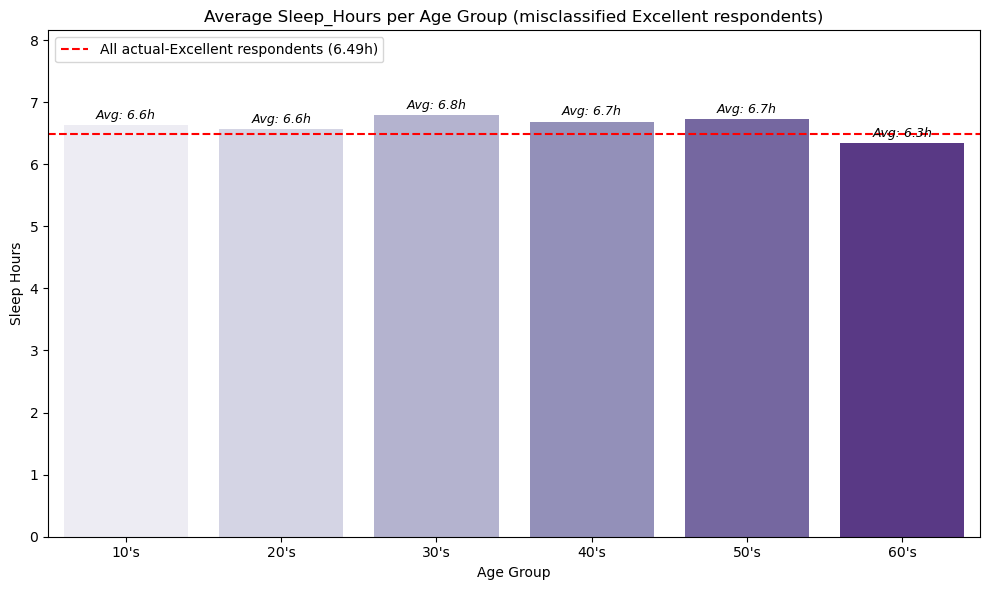

In [109]:
refTest = MAtest[MAtest['Actual'] == 3]
plot_age_mean(MATest, refTest['Sleep_Hours'].mean(), 'Sleep_Hours', 'Purples')

## Average 'Physical_Activity_Hours' per age group - Test set

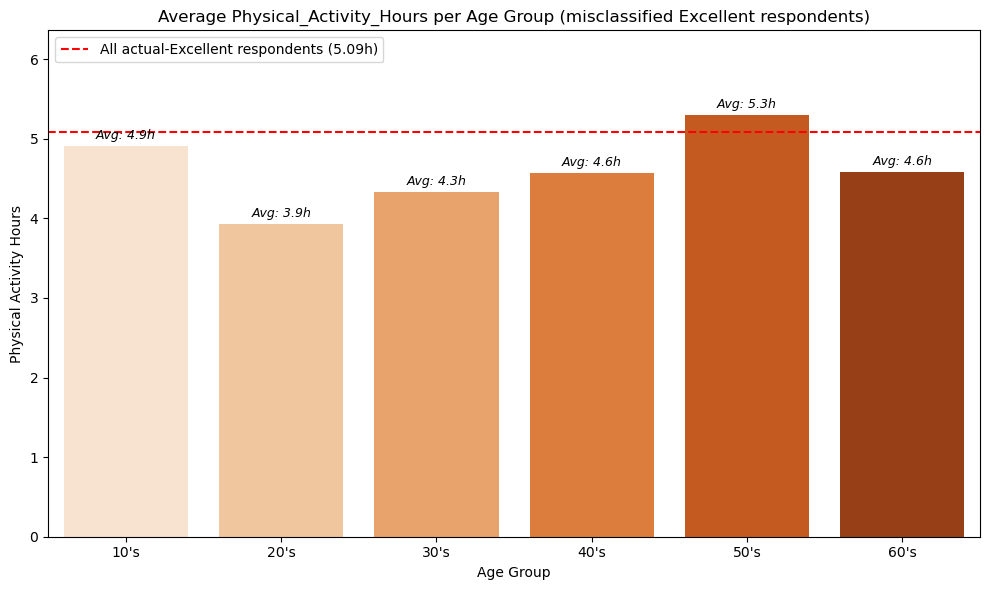

In [110]:
plot_age_mean(MATest, refTest['Physical_Activity_Hours'].mean(), 'Physical_Activity_Hours', 'Oranges')

## Average 'Gaming_Hours' per age group - Test set

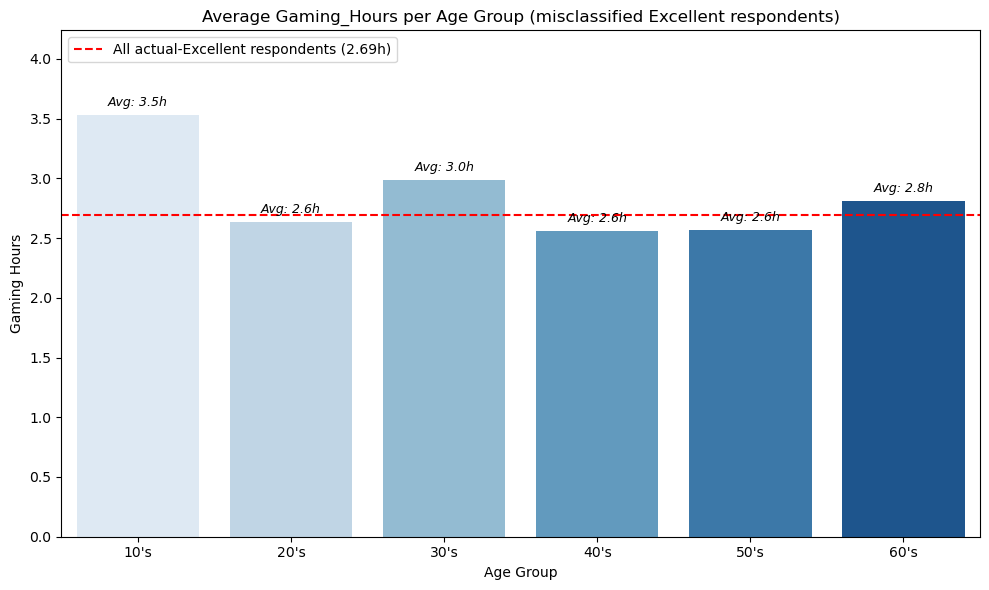

In [111]:
plot_age_mean(MATest, refTest['Gaming_Hours'].mean(), 'Gaming_Hours', 'Blues')

In [112]:
summarize_errors(MAtest, MATest, 'Test set')

Test set: 395 of 504 actual-Excellent respondents (78.4%) were predicted as Poor/Fair/Good
Misclassified respondents per age group: {"10's": 10, "20's": 65, "30's": 78, "40's": 94, "50's": 79, "60's": 69}

Sleep_Hours: all Excellent = 6.49h | misclassified = 6.64h
    by age group: highest = 30's (6.8h), lowest = 60's (6.3h), spread = 0.45h
Physical_Activity_Hours: all Excellent = 5.09h | misclassified = 4.57h
    by age group: highest = 50's (5.3h), lowest = 20's (3.9h), spread = 1.38h
Gaming_Hours: all Excellent = 2.69h | misclassified = 2.73h
    by age group: highest = 10's (3.5h), lowest = 40's (2.6h), spread = 0.97h


On the Test set, 395 of the 504 respondents whose actual status is **Excellent** (78.4%) were predicted as Poor, Fair, or Good, again close to what random guessing would give.

Among these misclassified respondents:

- **'Sleep_Hours'**: the average is 6.64 hours (all Excellent respondents: 6.49). The highest age group is the **30's** (6.8 hours) and the lowest the 60's (6.3 hours).
- **'Physical_Activity_Hours'**: the average is 4.57 hours (all Excellent respondents: 5.09). The highest age group is the **50's** (5.3 hours) and the lowest the 20's (3.9 hours).
- **'Gaming_Hours'**: the average is 2.73 hours (all Excellent respondents: 2.69). The highest age group is the **10's** (3.5 hours) but it contains only 10 respondents; the lowest is the 40's (2.6 hours).

The overall picture is the same as on the Train set: the misclassified respondents sleep slightly more and are less active than the average Excellent respondent, which reflects how the model splits respondents rather than a real pattern. The age groups with the highest and lowest averages differ between the Train and Test sets for all three variables (for example, the highest sleep average is in the 10's on Train but in the 30's on Test), and the small age groups (10's: only 10 misclassified respondents) make their averages unstable. There is therefore no age group in which the model errors clearly concentrate.

# xi. Conclusion

## Conclusion

**The available features do not predict `Mental_Health_Status`, so no model built here can be used to support the diagnosis.**

* **Best model.** Following the cross-validation recall, Logistic Regression is the best of the seven models (CV macro recall 0.254, test macro recall 0.258) and was tuned (`C = 0.01`). After tuning, the test macro recall is 0.260 and the test accuracy is 0.260, with a 95% confidence interval of 0.241-0.279. This interval contains 0.25, the accuracy of random guessing with four balanced classes (binomial test p = 0.170), and the Dummy baseline scores 0.251.
* **No model works.** None of the seven models is significantly better than random guessing, not even before correcting for testing seven models at once (smallest p-value 0.211), and five of them (KNN, SVM, Decision Tree, Random Forest, XGBoost) overfit strongly (recall gap between train and test from 0.17 to 0.75). The Decision Tree and Random Forest reach 1.00 on the train set and about 0.25 on the test set. Tuning did not help (CV recall 0.254 to 0.255), and grouping the target into two classes did not help either (ROC-AUC about 0.50).
* **The model is not safe for the main objective.** For the **Poor** class, the most important one for NAC, the tuned model has a recall of 0.22 and a precision of 0.24 on the test set: it misses about 78% of Poor respondents, and about 77-78% of actual Excellent respondents are labeled as Poor, Fair, or Good. Using it would mean choosing therapy almost at random.
* **The data show no signal at all, from several independent angles.** None of the 12 feature-target tests (Chi-Square and Kendall's Tau) is significant (smallest p = 0.092); Mutual Information is only marginally above noise for two features; permutation importance is below 0.01 for every feature; and out of 20 EDA tests only two reach p < 0.05 (p = 0.020 with r = 0.023, and p = 0.036 for a 5-minute difference in sleep), which is what chance produces and neither survives a Bonferroni correction.
* **Data quality is a likely cause.** The usage columns contradict each other (27% of respondents spend more time on social media than their total technology usage, and 21% have sleep, physical activity, and screen time adding up to more than 24 hours), the numerical columns are close to uniform, the four classes are almost perfectly balanced, and all correlations are about zero. This pattern is typical of variables that were recorded or generated independently of each other and of the target. The source of the dataset could not be verified here, but if the variables are independent of the target, no algorithm can learn from them.
* **Limitations.** The conclusion is based on one 80/20 split plus 5-fold cross-validation, on self-reported features, and on the four-class target as defined in the dataset. The XGBoost results come from a separate run of the same code.

In short, the best model (tuned Logistic Regression) does not overfit but is also no better than guessing, and the more flexible models either overfit strongly or stay at chance level. The honest result of this project is that the available data cannot support a mental health status prediction.

## Recommendation

1. **Do not use `model.pkl` for diagnosis or therapy selection.** It performs at the level of random guessing and would not reduce the wrong therapy choices NAC wants to avoid. It can be kept only as a baseline for future comparison.
2. **Validate the data before collecting more of it.** Check how the dataset was collected or generated, who filled in each column, and how `Mental_Health_Status` was defined. Fix the inconsistent usage columns (for example, social media hours above total technology usage, or daily hours that add up to more than 24) by giving every question a clear definition and a validation rule at data entry.
3. **Collect features that are expected to carry information about mental health.** Examples are validated clinical screening scales (such as PHQ-9 and GAD-7), clinician-assessed diagnosis and treatment history, sleep quality (not only duration), life events, and medication or therapy history. The label should come from a clinician assessment rather than a self-reported category.
4. **Do not spend more effort on tuning or more complex algorithms with the current data.** Seven different model families, cross-validated tuning, and a two-class target all stay at chance level, so the limit is the information in the features, not the model.
5. **Set an acceptance rule before any future model is used.** For example: it must beat the Dummy baseline with a confidence interval that stays above chance on a held-out set, reach an agreed recall for the **Poor** class, and be re-checked on new data (ideally with nested cross-validation and a final test on data collected later).
6. **Until then, keep the clinician's assessment and validated screening tools as the basis for deciding therapy**, and use the model, if at all, only as a research tool.